<a href="https://colab.research.google.com/github/CharlesSnt/PFE/blob/main/MLP_discovery_ASNR_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Installation de la librairie pour lire les .7z
!pip install py7zr

# 2. Upload du fichier .7z
from google.colab import files
uploaded = files.upload()  # Une fenêtre va s'ouvrir pour choisir ton fichier

# 3. Extraction
import py7zr
import os

archive_name = list(uploaded.keys())[0]  # Récupère le nom du fichier uploadé
extract_dir = "/content/data/"

with py7zr.SevenZipFile(archive_name, mode='r') as z:
    z.extractall(path=extract_dir)

print("Fichiers extraits :")
fichiers = sorted(os.listdir(extract_dir))
print(f"Nombre de fichiers : {len(fichiers)}")
print("Premiers fichiers :", fichiers[:5])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 18.3 MB/s eta 0:00:00


Saving ProjetIA.7z to ProjetIA.7z
Fichiers extraits :
Nombre de fichiers : 200
Premiers fichiers : ['Data_1.txt', 'Data_10.txt', 'Data_100.txt', 'Data_101.txt', 'Data_102.txt']


In [2]:
# 4. Lecture d'un fichier pour inspecter la structure
import pandas as pd
import numpy as np

# Charge le premier fichier pour voir ce qu'il contient
premier_fichier = os.path.join(extract_dir, fichiers[0])

# Essaie d'abord avec pandas (fonctionne pour csv, txt, dat...)
try:
    df = pd.read_csv(premier_fichier)
    print(df.head())
    print("\nColonnes :", df.columns.tolist())
    print("Shape :", df.shape)
except Exception as e:
    print(f"Erreur CSV : {e}")
    # Si ça ne marche pas, on regarde les premières lignes brutes
    with open(premier_fichier, 'r') as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i > 10:
                break

Erreur CSV : Error tokenizing data. C error: Expected 1 fields in line 6, saw 6


[Name]
Velocity

[Data]
X [ m ], Y [ m ], Z [ m ], Velocity u [ m s^-1 ], Velocity v [ m s^-1 ], Velocity w [ m s^-1 ]
2.50000000e-01, 0.00000000e+00, 4.75000000e+00, 1.65407528e-05, 1.08359265e-04, 2.65731424e-01
2.50000000e-01, 0.00000000e+00, 4.73484850e+00, 1.67262442e-05, 1.08077737e-04, 2.67556667e-01
2.50000000e-01, 0.00000000e+00, 4.71969700e+00, 1.69112427e-05, 1.07232656e-04, 2.69381374e-01
2.50000000e-01, 0.00000000e+00, 4.70454550e+00, 1.70962539e-05, 1.06387568e-04, 2.71206111e-01
2.50000000e-01, 0.00000000e+00, 4.68939400e+00, 1.72812506e-05, 1.05542495e-04, 2.73030818e-01
2.50000000e-01, 0.00000000e+00, 4.67424250e+00, 1.74667384e-05, 1.04697414e-04, 2.74855554e-01


In [3]:
import pandas as pd
import numpy as np
import os

extract_dir = "/content/data/"
fichiers = sorted(os.listdir(extract_dir))

def lire_fichier(path):
    # Skip 6 rows to start reading directly from the numerical data
    # Then, treat the remaining data as having no header, and manually assign column names.
    df = pd.read_csv(path, skiprows=6, sep=',', header=None)
    df.columns = ['X', 'Y', 'Z', 'u', 'v', 'w']

    # Convert columns to numeric, coercing errors will turn non-numeric values into NaN
    # Then drop any rows that might have non-numeric values (e.g., if the header row slipped through)
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna().reset_index(drop=True)

    return df

# Test sur le premier fichier
df = lire_fichier(os.path.join(extract_dir, fichiers[0]))
print(df.head())
print("\nShape :", df.shape)
print("\nStats :")
print(df.describe())

      X    Y         Z         u         v         w
0  0.25  0.0  4.750000  0.000017  0.000108  0.265731
1  0.25  0.0  4.734849  0.000017  0.000108  0.267557
2  0.25  0.0  4.719697  0.000017  0.000107  0.269381
3  0.25  0.0  4.704546  0.000017  0.000106  0.271206
4  0.25  0.0  4.689394  0.000017  0.000106  0.273031

Shape : (5000, 6)

Stats :
             X            Y            Z            u            v  \
count  5000.00  5000.000000  5000.000000  5000.000000  5000.000000   
mean      0.25     0.250000     4.000000    -0.000003    -0.000015   
std       0.00     0.147268     0.437408     0.000028     0.001083   
min       0.25     0.000000     3.250000    -0.000028    -0.002032   
25%       0.25     0.122449     3.625000    -0.000022    -0.000937   
50%       0.25     0.250000     4.000000    -0.000020    -0.000022   
75%       0.25     0.377551     4.375000     0.000019     0.000901   
max       0.25     0.500000     4.750000     0.000069     0.002003   

                 w  
co

In [4]:
# Vérification rapide
print("X unique :", df['X'].unique())        # Doit être constant (ton plan)
print("Y range :", df['Y'].min(), "->", df['Y'].max())
print("Z range :", df['Z'].min(), "->", df['Z'].max())
print("v range :", df['v'].min(), "->", df['v'].max())
print("w range :", df['w'].min(), "->", df['w'].max())

X unique : [0.25]
Y range : 0.0 -> 0.5
Z range : 3.25 -> 4.75
v range : -0.00203205389 -> 0.00200327742
w range : 0.265731424 -> 1.1502192


v ∈ [-0.002, 0.002 m/s] → très faible, composante transverse quasi-nulle

w ∈ [0.27, 1.15 m/s] → composante principale de l'écoulement, c'est le flux dominant

# Identifier la géométrie

In [5]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np

# Charger tous les fichiers et concaténer
import os

all_dfs = []
for f in fichiers:
    df_temp = lire_fichier(os.path.join(extract_dir, f))
    all_dfs.append(df_temp)

df_all = pd.concat(all_dfs, ignore_index=True)
print(f"Total points : {len(df_all)}")
print(f"Y unique values ({df_all['Y'].nunique()}) :", sorted(df_all['Y'].unique()))
print(f"Z unique values ({df_all['Z'].nunique()}) :", sorted(df_all['Z'].unique()))

Total points : 1000000
Y unique values (50) : [np.float64(0.0), np.float64(0.0102040768), np.float64(0.0204081684), np.float64(0.0306122452), np.float64(0.040816322), np.float64(0.0510204136), np.float64(0.0612244904), np.float64(0.0714285672), np.float64(0.0816326439), np.float64(0.0918367356), np.float64(0.102040812), np.float64(0.112244904), np.float64(0.122448981), np.float64(0.132653058), np.float64(0.142857134), np.float64(0.153061226), np.float64(0.163265303), np.float64(0.17346938), np.float64(0.183673471), np.float64(0.193877548), np.float64(0.204081625), np.float64(0.214285716), np.float64(0.224489793), np.float64(0.23469387), np.float64(0.244897962), np.float64(0.255102038), np.float64(0.265306115), np.float64(0.275510192), np.float64(0.285714269), np.float64(0.295918375), np.float64(0.306122452), np.float64(0.316326529), np.float64(0.326530606), np.float64(0.336734682), np.float64(0.346938759), np.float64(0.357142836), np.float64(0.367346942), np.float64(0.377551019), np.fl

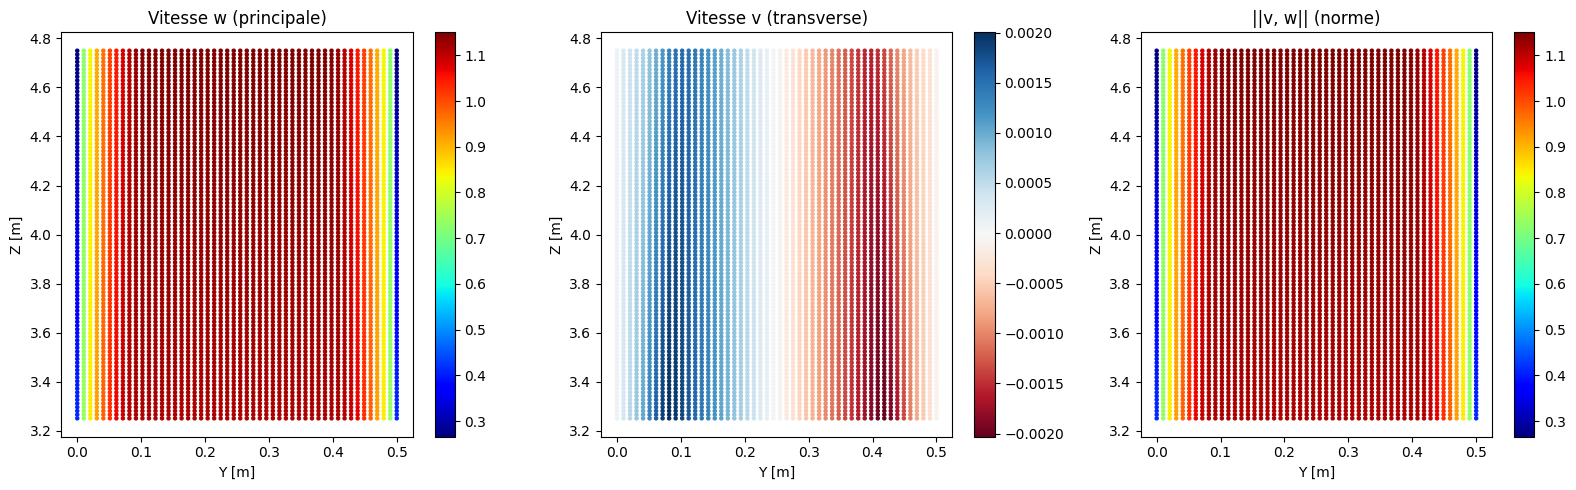

In [6]:
# Visualisation de la vitesse w (dominante) sur le plan Y-Z
# On prend un seul fichier (un instant)
df_single = lire_fichier(os.path.join(extract_dir, fichiers[0]))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# W (vitesse principale)
sc1 = axes[0].scatter(df_single['Y'], df_single['Z'], c=df_single['w'],
                       cmap='jet', s=5)
axes[0].set_title('Vitesse w (principale)')
axes[0].set_xlabel('Y [m]'); axes[0].set_ylabel('Z [m]')
plt.colorbar(sc1, ax=axes[0])

# V (vitesse transverse)
sc2 = axes[1].scatter(df_single['Y'], df_single['Z'], c=df_single['v'],
                       cmap='RdBu', s=5)
axes[1].set_title('Vitesse v (transverse)')
axes[1].set_xlabel('Y [m]'); axes[1].set_ylabel('Z [m]')
plt.colorbar(sc2, ax=axes[1])

# Norme vitesse
norm_v = np.sqrt(df_single['v']**2 + df_single['w']**2)
sc3 = axes[2].scatter(df_single['Y'], df_single['Z'], c=norm_v,
                       cmap='jet', s=5)
axes[2].set_title('||v, w|| (norme)')
axes[2].set_xlabel('Y [m]'); axes[2].set_ylabel('Z [m]')
plt.colorbar(sc3, ax=axes[2])

plt.tight_layout()
plt.savefig('champ_vitesse.png', dpi=150)
plt.show()

In [7]:
# Zoom sur les bords pour détecter les parois
# Une paroi = vitesse nulle (condition no-slip)
print("=== Bord Y=0 ===")
bord_Y0 = df_single[df_single['Y'] == df_single['Y'].min()]
print(bord_Y0[['Y', 'Z', 'v', 'w']].describe())

print("\n=== Bord Y=0.5 ===")
bord_Ymax = df_single[df_single['Y'] == df_single['Y'].max()]
print(bord_Ymax[['Y', 'Z', 'v', 'w']].describe())

print("\n=== Bord Z=3.25 ===")
bord_Zmin = df_single[df_single['Z'] == df_single['Z'].min()]
print(bord_Zmin[['Y', 'Z', 'v', 'w']].describe())

print("\n=== Bord Z=4.75 ===")
bord_Zmax = df_single[df_single['Z'] == df_single['Z'].max()]
print(bord_Zmax[['Y', 'Z', 'v', 'w']].describe())

=== Bord Y=0 ===
           Y           Z           v           w
count  100.0  100.000000  100.000000  100.000000
mean     0.0    4.000000    0.000101    0.345492
std      0.0    0.439568    0.000004    0.043451
min      0.0    3.250000    0.000093    0.265731
25%      0.0    3.625000    0.000098    0.309280
50%      0.0    4.000000    0.000103    0.348366
75%      0.0    4.375000    0.000105    0.383201
max      0.0    4.750000    0.000108    0.414127

=== Bord Y=0.5 ===
           Y           Z           v           w
count  100.0  100.000000  100.000000  100.000000
mean     0.5    4.000000   -0.000102    0.345558
std      0.0    0.439568    0.000004    0.043477
min      0.5    3.250000   -0.000108    0.265756
25%      0.5    3.625000   -0.000105    0.309361
50%      0.5    4.000000   -0.000103    0.348430
75%      0.5    4.375000   -0.000098    0.383287
max      0.5    4.750000   -0.000093    0.414241

=== Bord Z=3.25 ===
               Y      Z          v          w
count  50.0000

Donc on a bien la confirmation que nous ne touchons aucune paroi

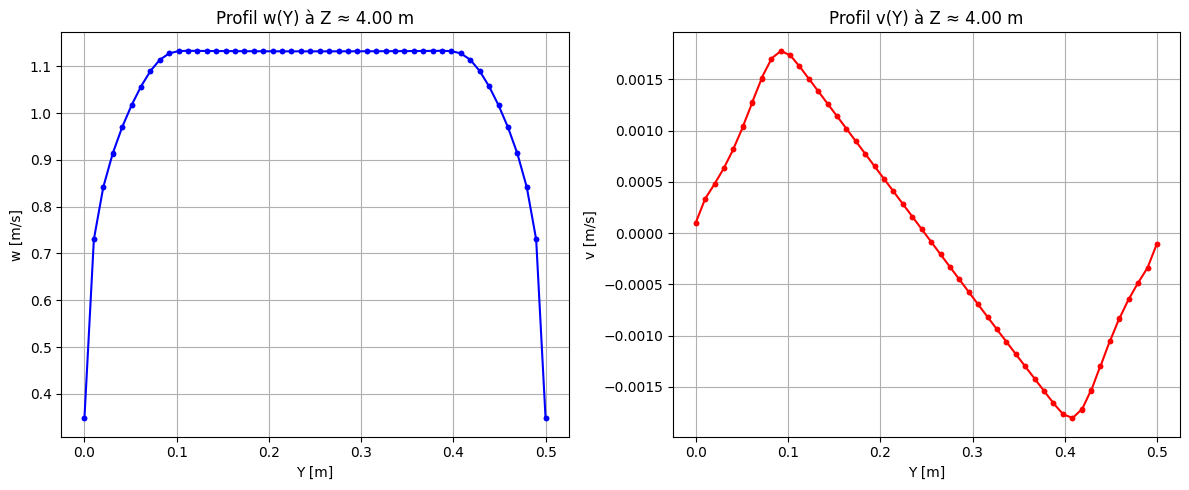

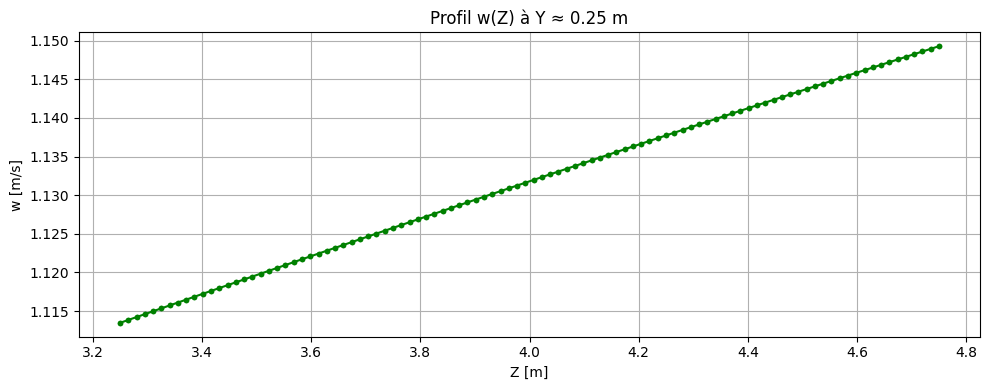

In [8]:
# Visualisation du profil de w en fonction de Y (à Z fixé ~ milieu)
df_single = lire_fichier(os.path.join(extract_dir, fichiers[0]))

Z_mid = df_single['Z'].median()
df_profil = df_single[np.abs(df_single['Z'] - Z_mid) < 0.01].sort_values('Y')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df_profil['Y'], df_profil['w'], 'b-o', markersize=3)
axes[0].set_xlabel('Y [m]')
axes[0].set_ylabel('w [m/s]')
axes[0].set_title(f'Profil w(Y) à Z ≈ {Z_mid:.2f} m')
axes[0].grid(True)

axes[1].plot(df_profil['Y'], df_profil['v'], 'r-o', markersize=3)
axes[1].set_xlabel('Y [m]')
axes[1].set_ylabel('v [m/s]')
axes[1].set_title(f'Profil v(Y) à Z ≈ {Z_mid:.2f} m')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('profil_vitesse.png', dpi=150)
plt.show()

# Profil w en fonction de Z (à Y fixé ~ milieu)
Y_mid = 0.25
df_profilZ = df_single[np.abs(df_single['Y'] - Y_mid) < 0.006].sort_values('Z')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_profilZ['Z'], df_profilZ['w'], 'g-o', markersize=3)
ax.set_xlabel('Z [m]')
ax.set_ylabel('w [m/s]')
ax.set_title(f'Profil w(Z) à Y ≈ {Y_mid} m')
ax.grid(True)
plt.tight_layout()
plt.savefig('profil_w_Z.png', dpi=150)
plt.show()

# PINN

In [9]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── Reproductibilité ──────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# ── Chargement et normalisation des données ───────────────────────
def lire_fichier(path):
    df = pd.read_csv(path, skiprows=5)
    df.columns = ['X', 'Y', 'Z', 'u', 'v', 'w']
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)
    return df

extract_dir = "/content/data/"
fichiers = sorted(os.listdir(extract_dir))

# On charge N fichiers et on moyenne (quasi-stationnarité)
N_fichiers = 20
dfs = [lire_fichier(os.path.join(extract_dir, f)) for f in fichiers[:N_fichiers]]
df_mean = pd.concat(dfs).groupby(['Y', 'Z'], as_index=False).mean()
print(f"Points après moyennage : {len(df_mean)}")

Y_raw = df_mean['Y'].values.astype(np.float32)
Z_raw = df_mean['Z'].values.astype(np.float32)
v_raw = df_mean['v'].values.astype(np.float32)
w_raw = df_mean['w'].values.astype(np.float32)

# Normalisation Min-Max → [0, 1]
Y_min, Y_max = Y_raw.min(), Y_raw.max()
Z_min, Z_max = Z_raw.min(), Z_raw.max()
v_min, v_max = v_raw.min(), v_raw.max()
w_min, w_max = w_raw.min(), w_raw.max()

def norm(x, xmin, xmax): return (x - xmin) / (xmax - xmin)
def denorm(x, xmin, xmax): return x * (xmax - xmin) + xmin

Y_n = norm(Y_raw, Y_min, Y_max)
Z_n = norm(Z_raw, Z_min, Z_max)
v_n = norm(v_raw, v_min, v_max)
w_n = norm(w_raw, w_min, w_max)

# Tenseurs
Y_t = torch.tensor(Y_n, dtype=torch.float32, device=device).unsqueeze(1)
Z_t = torch.tensor(Z_n, dtype=torch.float32, device=device).unsqueeze(1)
v_t = torch.tensor(v_n, dtype=torch.float32, device=device).unsqueeze(1)
w_t = torch.tensor(w_n, dtype=torch.float32, device=device).unsqueeze(1)
print("Données chargées")

Device : cuda
Points après moyennage : 5000
Données chargées


In [33]:
# MLP
class PINN_Stream(nn.Module):
    def __init__(self, hidden_layers=6, neurons=64):
        super().__init__()
        layers = [nn.Linear(2, neurons), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(neurons, neurons), nn.Tanh()]
        # Une seule sortie : ψ (fonction de stream)
        layers += [nn.Linear(neurons, 1)]
        self.net = nn.Sequential(*layers)

        # log(λ) pour forcer λ > 0, initialisés aux valeurs physiques
        self.log_lambda1 = nn.Parameter(torch.tensor([0.2],   device=device))  # log(1.225)
        self.log_lambda2 = nn.Parameter(torch.tensor([-10.9], device=device))  # log(1.8e-5)

    @property
    def lambda1(self):
        return torch.exp(self.log_lambda1)

    @property
    def lambda2(self):
        return torch.exp(self.log_lambda2)

    def forward(self, Y, Z):
        """Retourne v, w dérivés de ψ — continuité satisfaite par construction"""
        Y.requires_grad_(True)
        Z.requires_grad_(True)
        inp = torch.cat([Y, Z], dim=1)
        psi = self.net(inp)

        # v =  ∂ψ/∂Z,   w = -∂ψ/∂Y
        v = torch.autograd.grad(psi, Z,
                grad_outputs=torch.ones_like(psi),
                create_graph=True)[0]
        w = -torch.autograd.grad(psi, Y,
                grad_outputs=torch.ones_like(psi),
                create_graph=True)[0]
        return v, w, psi

model = PINN_Stream(hidden_layers=6, neurons=64).to(device)
print(f"λ1 initial = {model.lambda1.item():.4f}  (cible: 1.225)")
print(f"λ2 initial = {model.lambda2.item():.2e}  (cible: 1.8e-5)")
print(f"Paramètres : {sum(p.numel() for p in model.parameters()):,}")

λ1 initial = 1.2214  (cible: 1.225)
λ2 initial = 1.85e-05  (cible: 1.8e-5)
Paramètres : 21,059


In [40]:
def ns_residual_stream(model, Y, Z):
    """
    Résidu NS via fonction de stream.
    Continuité automatiquement satisfaite.
    On calcule le rotationnel de NS pour éliminer p.
    """
    Y = Y.clone().detach().requires_grad_(True)
    Z = Z.clone().detach().requires_grad_(True)

    Ly = float(Y_max - Y_min)   # 0.5 m
    Lz = float(Z_max - Z_min)   # 1.5 m
    Lv = float(v_max - v_min)
    Lw = float(w_max - w_min)

    def grad(f, x):
        return torch.autograd.grad(f, x,
               grad_outputs=torch.ones_like(f),
               create_graph=True)[0]

    v_pred, w_pred, _ = model(Y, Z)

    # --- Gradients dans l'espace normalisé puis conversion physique ---
    v_Y_n = grad(v_pred, Y);  v_Z_n = grad(v_pred, Z)
    w_Y_n = grad(w_pred, Y);  w_Z_n = grad(w_pred, Z)

    v_Y = (Lv/Ly)*v_Y_n;  v_Z = (Lv/Lz)*v_Z_n
    w_Y = (Lw/Ly)*w_Y_n;  w_Z = (Lw/Lz)*w_Z_n

    v_YY = (Lv/Ly**2)*grad(v_Y_n, Y);  v_ZZ = (Lv/Lz**2)*grad(v_Z_n, Z)
    w_YY = (Lw/Ly**2)*grad(w_Y_n, Y);  w_ZZ = (Lw/Lz**2)*grad(w_Z_n, Z)

    # Dérivées 3e ordre pour le rotationnel
    # v_YYY = (Lv/Ly**3)*grad(grad(v_Y_n, Y), Y)
    # v_YZZ = (Lv/(Ly*Lz**2))*grad(grad(v_Z_n, Z), Y)
    # w_YYZ = (Lw/(Ly**2*Lz))*grad(grad(w_Y_n, Y), Z)
    # w_ZZZ = (Lw/Lz**3)*grad(grad(w_Z_n, Z), Z)

    # Vitesses physiques
    v_phys = v_pred * Lv + float(v_min)
    w_phys = w_pred * Lw + float(w_min)

    lam1 = model.lambda1
    lam2 = model.lambda2

    # Rotationnel de NS (élimine p) : (Ceci est une tentative de rotationnel,
    # mais la version simplifiée est préférée et plus stable numériquement)
    # rot = (lam1 * (w_Y*v_Y + v_phys*w_YY + w_Z*w_Y + w_phys*w_ZY_approx # w_ZY_approx not defined
    #              - v_Z*v_Z - v_phys*v_ZZ - w_Z*v_Z)
    #      - lam2 * (w_YYY + w_YZZ - v_YYZ - v_ZZZ))

    # Version simplifiée plus stable numériquement :
    # On garde séparément les deux équations momentum sans p
    # en utilisant la continuité (déjà satisfaite) pour simplifier
    ns_v = lam1*(v_phys*v_Y + w_phys*v_Z) - lam2*(v_YY + v_ZZ)
    ns_w = lam1*(v_phys*w_Y + w_phys*w_Z) - lam2*(w_YY + w_ZZ)

    # Normalisation par U²/L pour équilibrer
    scale = U_ref**2 / L_ref
    return ns_v/scale, ns_w/scale

In [41]:
def compute_loss_stream(log=False):
    # Sous-échantillonnage pour la physique
    idx = torch.randperm(len(Y_t), device=device)[:500]
    Y_col = Y_t[idx]
    Z_col = Z_t[idx]

    # Prédictions sur tous les points
    Y_req = Y_t.clone().detach().requires_grad_(True)
    Z_req = Z_t.clone().detach().requires_grad_(True)
    v_pred, w_pred, _ = model(Y_req, Z_req)

    # 1. Loss données
    loss_data = (torch.mean((v_pred - v_t)**2) +
                 torch.mean((w_pred - w_t)**2))

    # 2. Loss physique
    ns_v, ns_w = ns_residual_stream(model, Y_col, Z_col)
    loss_phys = torch.mean(ns_v**2) + torch.mean(ns_w**2)

    # 3. Loss BC (bords Y=0 et Y=0.5)
    Y_bc_req = Y_bc.clone().detach().requires_grad_(True)
    Z_bc_req = Z_bc.clone().detach().requires_grad_(True)
    v_bc_pred, w_bc_pred, _ = model(Y_bc_req, Z_bc_req)
    loss_bc = (torch.mean((v_bc_pred - v_bc)**2) +
               torch.mean((w_bc_pred - w_bc)**2))

    loss_total = w_data*loss_data + w_phys*loss_phys + w_bc*loss_bc

    if log:
        loss_history['total'].append(loss_total.item())
        loss_history['data'].append(loss_data.item())
        loss_history['phys'].append(loss_phys.item())
        loss_history['bc'].append(loss_bc.item())
        loss_history['lambda1'].append(model.lambda1.item())
        loss_history['lambda2'].append(model.lambda2.item())

    return loss_total, loss_data, loss_phys, loss_bc

In [42]:
# ── Entraînement Phase 1 : Adam avec curriculum ───────────────────
print("=== PHASE 1 : Adam ===")

loss_history = {'total':[], 'data':[], 'phys':[],
                'bc':[], 'lambda1':[], 'lambda2':[]}

w_data, w_bc = 1.0, 1.0
N_adam = 8000

optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer_adam, patience=500,
                               factor=0.5, min_lr=1e-6)

for epoch in range(N_adam):
    # Curriculum : w_phys croît de 0.001 → 0.5
    w_phys = 0.001 + 0.499 * (epoch / N_adam)

    optimizer_adam.zero_grad()
    loss, loss_data, loss_phys, loss_bc = compute_loss_stream(log=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer_adam.step()
    scheduler.step(loss)

    if epoch % 500 == 0:
        print(f"[Adam] {epoch:5d} | "
              f"Loss:{loss.item():.3e} | "
              f"Data:{loss_data.item():.3e} | "
              f"Phys:{loss_phys.item():.3e} | "
              f"w_phys:{w_phys:.4f} | "
              f"λ1:{model.lambda1.item():.4f} | "
              f"λ2:{model.lambda2.item():.2e}")

print(f"\nFin Adam → λ1={model.lambda1.item():.5f}, λ2={model.lambda2.item():.2e}")

# ── Phase 2 : L-BFGS ─────────────────────────────────────────────
print("\n=== PHASE 2 : L-BFGS ===")
w_phys = 0.5  # poids fixe pour L-BFGS

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=50000,
    tolerance_grad=1e-9, tolerance_change=1e-11,
    history_size=50, line_search_fn='strong_wolfe')

lbfgs_iter = [0]

def closure():
    optimizer_lbfgs.zero_grad()
    loss, loss_data, loss_phys, loss_bc = compute_loss_stream(log=True)
    loss.backward()
    lbfgs_iter[0] += 1
    if lbfgs_iter[0] % 200 == 0:
        print(f"[L-BFGS] {lbfgs_iter[0]:5d} | "
              f"Loss:{loss.item():.3e} | "
              f"λ1:{model.lambda1.item():.5f} | "
              f"λ2:{model.lambda2.item():.2e}")
    return loss

optimizer_lbfgs.step(closure)

print(f"\n=== Résultats finaux ===")
print(f"λ1 = {model.lambda1.item():.6f}  (cible ρ = 1.225 kg/m³)")
print(f"λ2 = {model.lambda2.item():.2e}  (cible μ_lam = 1.8e-5 Pa·s)")
print(f"   → ratio λ2/μ_lam = {model.lambda2.item()/1.8e-5:.1f}x  "
      f"(>1 = viscosité turbulente)")

=== PHASE 1 : Adam ===
[Adam]     0 | Loss:2.424e+00 | Data:1.156e+00 | Phys:2.648e-08 | w_phys:0.0010 | λ1:1.2214 | λ2:1.85e-05
[Adam]   500 | Loss:9.845e-02 | Data:8.780e-02 | Phys:1.331e-03 | w_phys:0.0322 | λ1:0.6371 | λ2:1.45e-05
[Adam]  1000 | Loss:9.215e-02 | Data:8.345e-02 | Phys:7.641e-04 | w_phys:0.0634 | λ1:0.3436 | λ2:7.74e-06
[Adam]  1500 | Loss:8.813e-02 | Data:8.207e-02 | Phys:3.411e-04 | w_phys:0.0946 | λ1:0.2167 | λ2:4.30e-06
[Adam]  2000 | Loss:8.405e-02 | Data:7.713e-02 | Phys:2.082e-04 | w_phys:0.1258 | λ1:0.1502 | λ2:2.43e-06
[Adam]  2500 | Loss:7.969e-02 | Data:7.554e-02 | Phys:1.491e-04 | w_phys:0.1569 | λ1:0.1032 | λ2:1.42e-06
[Adam]  3000 | Loss:8.020e-02 | Data:7.516e-02 | Phys:8.941e-05 | w_phys:0.1881 | λ1:0.0762 | λ2:9.89e-07
[Adam]  3500 | Loss:7.668e-02 | Data:7.224e-02 | Phys:5.381e-05 | w_phys:0.2193 | λ1:0.0575 | λ2:7.27e-07
[Adam]  4000 | Loss:7.779e-02 | Data:7.382e-02 | Phys:3.626e-05 | w_phys:0.2505 | λ1:0.0451 | λ2:5.63e-07
[Adam]  4500 | Loss:7.6

In [28]:
# Grandeurs de référence physiques
rho_ref = 1.225      # kg/m³
mu_ref  = 1.8e-5     # Pa·s
U_ref   = float(w_max)   # vitesse de référence ~ 1.15 m/s
L_ref   = float(Ly)      # longueur de référence ~ 0.5 m
Re      = rho_ref * U_ref * L_ref / mu_ref
print(f"Reynolds estimé : Re = {Re:.0f}")
# → Re ~ 39 000 : turbulent, cohérent !

# Dans NS adimensionné :
# λ1_adim = 1  (=1 par définition)
# λ2_adim = 1/Re ~ 2.5e-5
print(f"1/Re = {1/Re:.2e}")

Reynolds estimé : Re = 39139
1/Re = 2.55e-05


In [29]:
# Résidu NS adimensionné
def ns_residual(model, Y, Z):
    Y.requires_grad_(True)
    Z.requires_grad_(True)

    Ly = float(Y_max - Y_min)
    Lz = float(Z_max - Z_min)
    Lv = float(v_max - v_min)
    Lw = float(w_max - w_min)

    # Normalisation adimensionnelle supplémentaire
    # On divise tout par U_ref et L_ref
    scale_conv = U_ref**2 / L_ref   # ordre de grandeur terme convectif
    scale_diff = mu_ref / (rho_ref * L_ref**2) * U_ref  # ordre diffusif

    v_pred, w_pred, p_pred = model(Y, Z)

    # Gradients normalisés → physiques
    def grad(out, inp):
        return torch.autograd.grad(out, inp,
               grad_outputs=torch.ones_like(out),
               create_graph=True)[0]

    v_Y_n = grad(v_pred, Y);  v_Z_n = grad(v_pred, Z)
    w_Y_n = grad(w_pred, Y);  w_Z_n = grad(w_pred, Z)
    p_Y_n = grad(p_pred, Y);  p_Z_n = grad(p_pred, Z)

    # Conversion physique
    v_Y = (Lv/Ly) * v_Y_n;  v_Z = (Lv/Lz) * v_Z_n
    w_Y = (Lw/Ly) * w_Y_n;  w_Z = (Lw/Lz) * w_Z_n
    p_Y = p_Y_n / Ly;        p_Z = p_Z_n / Lz

    v_YY = (Lv/Ly**2) * grad(v_Y_n, Y)
    v_ZZ = (Lv/Lz**2) * grad(v_Z_n, Z)
    w_YY = (Lw/Ly**2) * grad(w_Y_n, Y)
    w_ZZ = (Lw/Lz**2) * grad(w_Z_n, Z)

    # Vitesses physiques
    v_phys = v_pred * Lv + float(v_min)
    w_phys = w_pred * Lw + float(w_min)

    lam1 = model.lambda1
    lam2 = model.lambda2

    # Résidus normalisés par scale_conv pour équilibrer les termes
    cont  = (v_Y + w_Z) / (U_ref / L_ref)
    ns_v  = (lam1*(v_phys*v_Y + w_phys*v_Z) + p_Y - lam2*(v_YY+v_ZZ)) / scale_conv
    ns_w  = (lam1*(v_phys*w_Y + w_phys*w_Z) + p_Z - lam2*(w_YY+w_ZZ)) / scale_conv

    return cont, ns_v, ns_w

In [22]:
# Points de colocation aux bords
N_col = 200  # points par bord

# Bords Y=0 et Y=1 (normalisés) avec valeurs de v,w issues des données
def get_boundary_points():
    # Bord Y=0
    idx_Y0   = np.where(Y_raw == Y_min)[0]
    # Bord Y=0.5
    idx_Ymax = np.where(Y_raw == Y_max)[0]

    Y_b = np.concatenate([Y_n[idx_Y0], Y_n[idx_Ymax]])
    Z_b = np.concatenate([Z_n[idx_Y0], Z_n[idx_Ymax]])
    v_b = np.concatenate([v_n[idx_Y0], v_n[idx_Ymax]])
    w_b = np.concatenate([w_n[idx_Y0], w_n[idx_Ymax]])

    return (torch.tensor(Y_b, dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(Z_b, dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(v_b, dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(w_b, dtype=torch.float32, device=device).unsqueeze(1))

Y_bc, Z_bc, v_bc, w_bc = get_boundary_points()
print(f"Points de colocation : {len(Y_bc)}")

Points de colocation : 200


In [22]:
# Entraînement

# Facteurs de normalisation
Ly = float(Y_max - Y_min)   # 0.5 m
Lz = float(Z_max - Z_min)   # 1.5 m
Lv = float(v_max - v_min)   # ~0.004 m/s
Lw = float(w_max - w_min)   # ~0.885 m/s
v_min_f = float(v_min)
w_min_f = float(w_min)

print(f"Ly={Ly:.4f}, Lz={Lz:.4f}, Lv={Lv:.6f}, Lw={Lw:.6f}")

# Poids de la loss
w_data = 1.0

def get_w_phys(epoch, n_total=8000):
    # De 0.01 à 1.0 sur la durée de l'entraînement
    return 0.01 + 0.99 * (epoch / n_total)
w_phys = get_w_phys(0)

w_bc   = 1.0

loss_history = {'total': [], 'data': [], 'phys': [], 'bc': [],
                'lambda1': [], 'lambda2': []}

def compute_loss(Y_in, Z_in, log=False):
    """Calcule la loss totale réutilisable pour Adam et L-BFGS"""

    # 1. Loss données
    v_pred, w_pred, _ = model(Y_t, Z_t)
    loss_data = torch.mean((v_pred - v_t)**2) + torch.mean((w_pred - w_t)**2)

    # 2. Loss physique sur sous-ensemble aléatoire
    idx = torch.randperm(len(Y_in), device=device)[:500]
    Y_col = Y_in[idx].clone().detach().requires_grad_(True)
    Z_col = Z_in[idx].clone().detach().requires_grad_(True)
    cont, ns_v, ns_w = ns_residual(model, Y_col, Z_col)
    loss_phys = torch.mean(cont**2) + torch.mean(ns_v**2) + torch.mean(ns_w**2)

    # 3. Loss conditions aux limites
    v_bc_pred, w_bc_pred, _ = model(Y_bc, Z_bc)
    loss_bc = (torch.mean((v_bc_pred - v_bc)**2) +
               torch.mean((w_bc_pred - w_bc)**2))

    loss_total = w_data * loss_data + w_phys * loss_phys + w_bc * loss_bc

    if log:
        loss_history['total'].append(loss_total.item())
        loss_history['data'].append(loss_data.item())
        loss_history['phys'].append(loss_phys.item())
        loss_history['bc'].append(loss_bc.item())
        loss_history['lambda1'].append(model.lambda1.item())
        loss_history['lambda2'].append(model.lambda2.item())

    return loss_total, loss_data, loss_phys, loss_bc


# Adam
print("\nPHASE 1 : Adam ")
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer_adam, patience=500,
                               factor=0.5, min_lr=1e-6)

N_adam = 8000

for epoch in range(N_adam):
    optimizer_adam.zero_grad()

    loss, loss_data, loss_phys, loss_bc = compute_loss(Y_t, Z_t, log=True)
    loss.backward()

    # Gradient clipping pour stabiliser l'entraînement
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer_adam.step()
    scheduler.step(loss)

    if epoch % 500 == 0:
        print(f"[Adam] Epoch {epoch:5d} | "
              f"Loss: {loss.item():.4e} | "
              f"Data: {loss_data.item():.4e} | "
              f"Phys: {loss_phys.item():.4e} | "
              f"BC: {loss_bc.item():.4e} | "
              f"λ1: {model.lambda1.item():.5f} | "
              f"λ2: {model.lambda2.item():.2e}")

print(f"\nFin Adam → λ1={model.lambda1.item():.6f}, λ2={model.lambda2.item():.2e}")

# L-BFGS

print("\n PHASE 2 : L-BFGS")
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=0.1,
    max_iter=50000,
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
    history_size=50,
    line_search_fn='strong_wolfe'
)

lbfgs_counter = [0]  # compteur via liste pour accès dans closure

def closure():
    optimizer_lbfgs.zero_grad()
    loss, loss_data, loss_phys, loss_bc = compute_loss(Y_t, Z_t, log=True)
    loss.backward()

    lbfgs_counter[0] += 1
    if lbfgs_counter[0] % 100 == 0:
        print(f"[L-BFGS] Iter {lbfgs_counter[0]:5d} | "
              f"Loss: {loss.item():.4e} | "
              f"λ1: {model.lambda1.item():.6f} | "
              f"λ2: {model.lambda2.item():.2e}")
    return loss

optimizer_lbfgs.step(closure)

print(f"\n=== Résultats finaux ===")
print(f"λ1 = {model.lambda1.item():.6f}  (référence ρ_air = 1.225 kg/m³)")
print(f"λ2 = {model.lambda2.item():.2e}  (référence μ_lam = 1.8e-5 Pa·s)")
print(f"    → si λ2 >> 1.8e-5 : viscosité turbulente effective, cohérent avec RANS")

Ly=0.5000, Lz=1.5000, Lv=0.004035, Lw=0.884488

PHASE 1 : Adam 


NameError: name 'ns_residual' is not defined

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

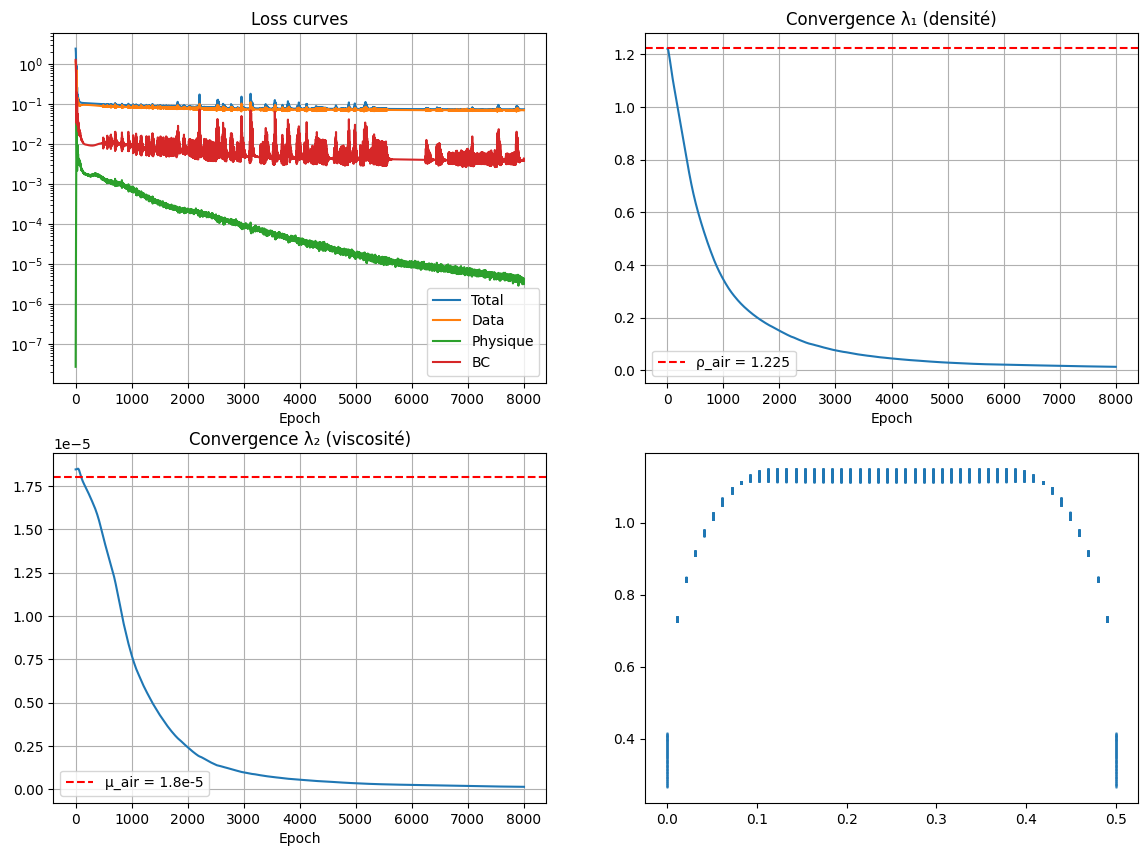

In [43]:
# Visualisation de la convergence
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].semilogy(loss_history['total'], label='Total')
axes[0,0].semilogy(loss_history['data'],  label='Data')
axes[0,0].semilogy(loss_history['phys'],  label='Physique')
axes[0,0].semilogy(loss_history['bc'],    label='BC')
axes[0,0].legend(); axes[0,0].set_title('Loss curves')
axes[0,0].set_xlabel('Epoch'); axes[0,0].grid(True)

axes[0,1].plot(loss_history['lambda1'])
axes[0,1].axhline(y=1.225, color='r', linestyle='--', label='ρ_air = 1.225')
axes[0,1].set_title('Convergence λ₁ (densité)')
axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(loss_history['lambda2'])
axes[1,0].axhline(y=1.8e-5, color='r', linestyle='--', label='μ_air = 1.8e-5')
axes[1,0].set_title('Convergence λ₂ (viscosité)')
axes[1,0].set_xlabel('Epoch'); axes[1,0].legend(); axes[1,0].grid(True)

# Dénormalisation
axes[1,1].scatter(Y_raw, w_raw, s=1, label='CFD', alpha=0.5)
with torch.no_grad():
    v_p, w_p, _ = model(Y_t, Z_t)
    w_pred_phys = w_p.cpu().numpy().flatten() * float(Lw) + float(w_min)
    w_cfd_phys  = w_raw

axes[1,1].scatter(Y_raw, w_cfd_phys,  s=1, label='CFD',  alpha=0.5)
axes[1,1].scatter(Y_raw, w_pred_phys, s=1, label='PINN', alpha=0.5)
axes[1,1].set_title('w prédit vs CFD')
axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.savefig('pinn_results.png', dpi=150)
plt.show()

print(f"\n=== Résultats finaux ===")
print(f"λ₁ = {model.lambda1.item():.6f}  (référence ρ_air = 1.225)")
print(f"λ₂ = {model.lambda2.item():.6f}  (référence μ_air = 1.8e-5)")

In [12]:
# Calcul du Reynolds et analyse des termes NS
import numpy as np

U_ref = float(w_max)
L_ref = float(Y_max - Y_min)
rho   = 1.225
mu    = 1.8e-5
nu    = mu / rho

Re = U_ref * L_ref / nu
print(f"Re = {Re:.0f}")

# Ordre de grandeur des termes NS dans tes données
dw_dY_approx = (w_raw.max() - w_raw.min()) / (Y_max - Y_min)
d2w_dY2_approx = dw_dY_approx / (Y_max - Y_min)

terme_convectif = rho * U_ref * dw_dY_approx
terme_diffusif  = mu  * d2w_dY2_approx

print(f"\nTerme convectif  ~ λ1 * u * ∂w/∂Y = {terme_convectif:.4f} Pa/m")
print(f"Terme diffusif   ~ λ2 * ∂²w/∂Y²  = {terme_diffusif:.6f} Pa/m")
print(f"Ratio convectif/diffusif = {terme_convectif/terme_diffusif:.0f}")
print(f"\n→ Re = {Re:.0f} : le terme diffusif est {terme_convectif/terme_diffusif:.0f}x plus petit")
print(f"→ Le réseau 'voit' surtout la convection, la diffusion est quasi-invisible")

Re = 39139

Terme convectif  ~ λ1 * u * ∂w/∂Y = 2.4925 Pa/m
Terme diffusif   ~ λ2 * ∂²w/∂Y²  = 0.000064 Pa/m
Ratio convectif/diffusif = 39139

→ Re = 39139 : le terme diffusif est 39139x plus petit
→ Le réseau 'voit' surtout la convection, la diffusion est quasi-invisible


In [13]:
# ── Constantes adimensionnelles ───────────────────────────────────
U_ref = float(w_max)
L_ref = float(Y_max - Y_min)
rho   = 1.225
mu    = 1.8e-5
Re    = rho * U_ref * L_ref / mu

print(f"Re = {Re:.0f}")
print(f"Cible λ1 = 1.0")
print(f"Cible λ2 = 1/Re = {1/Re:.6f}")

# Adimensionnement des données
# Vitesses : divisées par U_ref
# Coordonnées : déjà normalisées dans [0,1] → on utilise ça comme espace adim
# La normalisation [0,1] correspond à L_ref=1 dans l'espace adim

v_adim = v_raw / U_ref   # ~[-0.002, 0.002]
w_adim = w_raw / U_ref   # ~[0.23, 1.0]

v_adim = v_adim.astype(np.float32)
w_adim = w_adim.astype(np.float32)

# Tenseurs adimensionnés
v_t_ad = torch.tensor(v_adim, dtype=torch.float32, device=device).unsqueeze(1)
w_t_ad = torch.tensor(w_adim, dtype=torch.float32, device=device).unsqueeze(1)

# Bords adimensionnés
v_bc_ad = v_bc * float(v_max - v_min) / U_ref + float(v_min) / U_ref
w_bc_ad = w_bc * float(w_max - w_min) / U_ref + float(w_min) / U_ref

print(f"\nv_adim range : {v_adim.min():.4f} → {v_adim.max():.4f}")
print(f"w_adim range : {w_adim.min():.4f} → {w_adim.max():.4f}")

Re = 39139
Cible λ1 = 1.0
Cible λ2 = 1/Re = 0.000026


NameError: name 'v_bc' is not defined

In [46]:
class PINN_Adim(nn.Module):
    """
    Entrées  : (Y_n, Z_n) ∈ [0,1]²  — coordonnées normalisées
    Sorties  : (v_adim, w_adim) via ψ — vitesses adimensionnées
    Cibles   : λ1 → 1.0,  λ2 → 1/Re ≈ 2.55e-5
    """
    def __init__(self, hidden_layers=6, neurons=64):
        super().__init__()
        layers = [nn.Linear(2, neurons), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(neurons, neurons), nn.Tanh()]
        layers += [nn.Linear(neurons, 1)]  # sortie : ψ
        self.net = nn.Sequential(*layers)

        # Initialisés exactement aux valeurs cibles
        # log(1.0) = 0.0
        # log(1/Re) = -log(Re)
        self.log_lam1 = nn.Parameter(torch.tensor([0.0],          device=device))
        self.log_lam2 = nn.Parameter(torch.tensor([-np.log(Re)],  device=device))

    @property
    def lambda1(self):
        return torch.exp(self.log_lam1)

    @property
    def lambda2(self):
        return torch.exp(self.log_lam2)

    def get_vw(self, Y, Z):
        """Dérive v et w depuis ψ → continuité satisfaite par construction"""
        Y = Y.requires_grad_(True) if not Y.requires_grad else Y
        Z = Z.requires_grad_(True) if not Z.requires_grad else Z
        psi = self.net(torch.cat([Y, Z], dim=1))
        v = torch.autograd.grad(psi, Z,
                grad_outputs=torch.ones_like(psi),
                create_graph=True)[0]
        w = -torch.autograd.grad(psi, Y,
                grad_outputs=torch.ones_like(psi),
                create_graph=True)[0]
        return v, w

model = PINN_Adim(hidden_layers=6, neurons=64).to(device)
print(f"λ1 initial = {model.lambda1.item():.6f}  (cible : 1.0)")
print(f"λ2 initial = {model.lambda2.item():.6f}  (cible : {1/Re:.6f})")

λ1 initial = 1.000000  (cible : 1.0)
λ2 initial = 0.000026  (cible : 0.000026)


In [21]:
#def ns_residual_adim(model, Y, Z):
    """
    Résidu NS entièrement adimensionné.
    Coordonnées ∈ [0,1], vitesses divisées par U_ref.
    Les deux termes (convectif et diffusif) sont du même ordre.
    """
    Y = Y.clone().detach().requires_grad_(True)
    Z = Z.clone().detach().requires_grad_(True)

    # Facteurs géométriques : les coords sont dans [0,1]
    # mais Y_phys = Y_n * Ly et Z_phys = Z_n * Lz
    # En adim avec L_ref=Ly : Ŷ = Y_phys/Ly = Y_n  ✓
    #                          Ẑ = Z_phys/Ly = Z_n * (Lz/Ly)
    aspect = float(Lz / L_ref)   # Lz/Ly ≈ 3.0

    def g(f, x):
        return torch.autograd.grad(f, x,
               grad_outputs=torch.ones_like(f),
               create_graph=True)[0]

    v, w = model.get_vw(Y, Z)

    # Dérivées dans l'espace normalisé
    # ∂/∂Ŷ = ∂/∂Y_n  (car Ŷ = Y_n quand L_ref=Ly)
    # ∂/∂Ẑ = (1/aspect) * ∂/∂Z_n
    v_Y = g(v, Y)
    v_Z = g(v, Z) / aspect
    w_Y = g(w, Y)
    w_Z = g(w, Z) / aspect

    v_YY = g(v_Y, Y)
    v_ZZ = g(g(v, Z), Z) / aspect**2
    w_YY = g(w_Y, Y)
    w_ZZ = g(g(w, Z), Z) / aspect**2

    lam1 = model.lambda1
    lam2 = model.lambda2

    # Résidus adimensionnés — les deux termes sont O(1)
    ns_v = lam1*(v*v_Y + w*v_Z) - lam2*(v_YY + v_ZZ)
    ns_w = lam1*(v*w_Y + w*w_Z) - lam2*(w_YY + w_ZZ)

    # Continuité (doit être ~0 par construction avec ψ, vérification)
    cont = v_Y + w_Z / aspect

    return ns_v, ns_w, cont

In [48]:
def compute_loss_adim(w_phys_cur, log=False):
    # Points de colocation aléatoires
    idx = torch.randperm(len(Y_t), device=device)[:500]
    Y_col = Y_t[idx]
    Z_col = Z_t[idx]

    # Loss données (espace adim)
    Y_d = Y_t.clone().detach().requires_grad_(True)
    Z_d = Z_t.clone().detach().requires_grad_(True)
    v_p, w_p = model.get_vw(Y_d, Z_d)
    loss_data = (torch.mean((v_p - v_t_ad)**2) +
                 torch.mean((w_p - w_t_ad)**2))

    # Loss physique
    ns_v, ns_w, cont = ns_residual_adim(model, Y_col, Z_col)
    loss_phys = (torch.mean(ns_v**2) +
                 torch.mean(ns_w**2) +
                 torch.mean(cont**2))

    # Loss BC
    Y_b = Y_bc.clone().detach().requires_grad_(True)
    Z_b = Z_bc.clone().detach().requires_grad_(True)
    v_bp, w_bp = model.get_vw(Y_b, Z_b)
    loss_bc = (torch.mean((v_bp - v_bc_ad)**2) +
               torch.mean((w_bp - w_bc_ad)**2))

    loss = 1.0*loss_data + w_phys_cur*loss_phys + 1.0*loss_bc

    if log:
        loss_history['total'].append(loss.item())
        loss_history['data'].append(loss_data.item())
        loss_history['phys'].append(loss_phys.item())
        loss_history['bc'].append(loss_bc.item())
        loss_history['lambda1'].append(model.lambda1.item())
        loss_history['lambda2'].append(model.lambda2.item())

    return loss, loss_data, loss_phys, loss_bc

In [50]:
# ── Phase 1 : Adam ────────────────────────────────────────────────
print("=== PHASE 1 : Adam ===")
loss_history = {k: [] for k in ['total','data','phys','bc','lambda1','lambda2']}

optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer_adam, patience=500,
                               factor=0.5, min_lr=1e-6)
N_adam = 10000

for epoch in range(N_adam):
    # Curriculum : 0.001 → 1.0
    w_phys_cur = 0.001 * (1000 ** (epoch / N_adam))

    optimizer_adam.zero_grad()
    loss, ld, lp, lbc = compute_loss_adim(w_phys_cur, log=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer_adam.step()
    scheduler.step(loss)

    if epoch % 1000 == 0:
        lr_cur = optimizer_adam.param_groups[0]['lr']
        print(f"[Adam] {epoch:5d} | "
              f"Loss:{loss.item():.3e} | "
              f"Data:{ld.item():.3e} | "
              f"Phys:{lp.item():.3e} | "
              f"w_phy:{w_phys_cur:.4f} | "
              f"λ1:{model.lambda1.item():.5f} | "
              f"λ2:{model.lambda2.item():.2e} | "
              f"lr:{lr_cur:.1e}")

print(f"\nFin Adam → λ1={model.lambda1.item():.5f}  "
      f"λ2={model.lambda2.item():.2e}")

# ── Phase 2 : L-BFGS ─────────────────────────────────────────────
print("\n=== PHASE 2 : L-BFGS ===")
w_phys_cur = 1.0

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=50000,
    tolerance_grad=1e-9, tolerance_change=1e-11,
    history_size=50, line_search_fn='strong_wolfe')

it = [0]
def closure():
    optimizer_lbfgs.zero_grad()
    loss, ld, lp, lbc = compute_loss_adim(w_phys_cur, log=True)
    loss.backward()
    it[0] += 1
    if it[0] % 500 == 0:
        print(f"[L-BFGS] {it[0]:5d} | Loss:{loss.item():.3e} | "
              f"λ1:{model.lambda1.item():.5f} | "
              f"λ2:{model.lambda2.item():.2e}")
    return loss

optimizer_lbfgs.step(closure)

print(f"\n=== Résultats finaux ===")
print(f"λ1 = {model.lambda1.item():.6f}   (cible : 1.0)")
print(f"λ2 = {model.lambda2.item():.6f}   (cible : {1/Re:.6f})")
print(f"Erreur λ1 : {abs(model.lambda1.item()-1.0)*100:.2f}%")
print(f"Erreur λ2 : {abs(model.lambda2.item()-1/Re)/(1/Re)*100:.2f}%")

=== PHASE 1 : Adam ===
[Adam]     0 | Loss:1.883e+00 | Data:8.674e-01 | Phys:2.020e-06 | w_phy:0.0010 | λ1:1.00000 | λ2:2.55e-05 | lr:1.0e-03
[Adam]  1000 | Loss:2.740e-02 | Data:2.440e-02 | Phys:5.458e-05 | w_phy:0.0020 | λ1:0.90712 | λ2:2.57e-05 | lr:1.0e-03
[Adam]  2000 | Loss:2.739e-02 | Data:2.440e-02 | Phys:5.876e-05 | w_phy:0.0040 | λ1:0.83172 | λ2:2.56e-05 | lr:1.0e-03
[Adam]  3000 | Loss:2.737e-02 | Data:2.439e-02 | Phys:5.933e-05 | w_phy:0.0079 | λ1:0.66523 | λ2:2.54e-05 | lr:1.0e-03
[Adam]  4000 | Loss:2.741e-02 | Data:2.371e-02 | Phys:4.715e-05 | w_phy:0.0158 | λ1:0.46247 | λ2:2.50e-05 | lr:1.0e-03
[Adam]  5000 | Loss:2.630e-02 | Data:2.413e-02 | Phys:1.745e-04 | w_phy:0.0316 | λ1:0.24237 | λ2:2.33e-05 | lr:1.0e-03
[Adam]  6000 | Loss:2.561e-02 | Data:2.353e-02 | Phys:1.207e-04 | w_phy:0.0631 | λ1:0.11998 | λ2:1.54e-05 | lr:1.0e-03
[Adam]  7000 | Loss:2.371e-02 | Data:2.195e-02 | Phys:1.837e-04 | w_phy:0.1259 | λ1:0.06687 | λ2:6.15e-06 | lr:1.0e-03
[Adam]  8000 | Loss:2.226

In [51]:
class PINN_FixedLam1(nn.Module):
    """
    λ₁ = 1 fixé (densité adimensionnée = 1 par définition)
    λ₂ = 1/Re est le seul paramètre à identifier
    Cible : λ₂ → 1/Re ≈ 2.55e-5
    """
    def __init__(self, hidden_layers=6, neurons=64):
        super().__init__()
        layers = [nn.Linear(2, neurons), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(neurons, neurons), nn.Tanh()]
        layers += [nn.Linear(neurons, 1)]
        self.net = nn.Sequential(*layers)

        # λ₁ fixé à 1, pas de gradient
        self.lambda1 = 1.0

        # Seul λ₂ est appris
        self.log_lam2 = nn.Parameter(torch.tensor([-np.log(Re)], device=device))

    @property
    def lambda2(self):
        return torch.exp(self.log_lam2)

    def get_vw(self, Y, Z):
        Y = Y.requires_grad_(True) if not Y.requires_grad else Y
        Z = Z.requires_grad_(True) if not Z.requires_grad else Z
        psi = self.net(torch.cat([Y, Z], dim=1))
        v =  torch.autograd.grad(psi, Z,
                grad_outputs=torch.ones_like(psi),
                create_graph=True)[0]
        w = -torch.autograd.grad(psi, Y,
                grad_outputs=torch.ones_like(psi),
                create_graph=True)[0]
        return v, w

model = PINN_FixedLam1(hidden_layers=6, neurons=64).to(device)
print(f"λ1 = {model.lambda1} (fixé)")
print(f"λ2 initial = {model.lambda2.item():.2e}  (cible : {1/Re:.2e})")

λ1 = 1.0 (fixé)
λ2 initial = 2.55e-05  (cible : 2.55e-05)


In [20]:
def ns_residual_fixed(model, Y, Z):
    Y = Y.clone().detach().requires_grad_(True)
    Z = Z.clone().detach().requires_grad_(True)

    aspect = float(Lz / L_ref)

    def g(f, x):
        return torch.autograd.grad(f, x,
               grad_outputs=torch.ones_like(f),
               create_graph=True)[0]

    v, w = model.get_vw(Y, Z)

    v_Y = g(v, Y);          v_Z = g(v, Z) / aspect
    w_Y = g(w, Y);          w_Z = g(w, Z) / aspect
    v_YY = g(v_Y, Y);       v_ZZ = g(g(v,Z),Z) / aspect**2
    w_YY = g(w_Y, Y);       w_ZZ = g(g(w,Z),Z) / aspect**2
    cont = v_Y + w_Z

    lam2 = model.lambda2

    # λ₁ = 1 fixé → terme convectif connu, λ₂ seul inconnu
    ns_v = 1.0*(v*v_Y + w*v_Z) - lam2*(v_YY + v_ZZ)
    ns_w = 1.0*(v*w_Y + w*w_Z) - lam2*(w_YY + w_ZZ)

    return ns_v, ns_w, cont


def compute_loss_fixed(w_phys_cur, log=False):
    idx = torch.randperm(len(Y_t), device=device)[:500]

    Y_d = Y_t.clone().detach().requires_grad_(True)
    Z_d = Z_t.clone().detach().requires_grad_(True)
    v_p, w_p = model.get_vw(Y_d, Z_d)
    loss_data = torch.mean((v_p - v_t_ad)**2) + torch.mean((w_p - w_t_ad)**2)

    ns_v, ns_w, cont = ns_residual_fixed(model, Y_t[idx], Z_t[idx])
    loss_phys = torch.mean(ns_v**2) + torch.mean(ns_w**2) + torch.mean(cont**2)

    Y_b = Y_bc.clone().detach().requires_grad_(True)
    Z_b = Z_bc.clone().detach().requires_grad_(True)
    v_bp, w_bp = model.get_vw(Y_b, Z_b)
    loss_bc = torch.mean((v_bp - v_bc_ad)**2) + torch.mean((w_bp - w_bc_ad)**2)

    loss = loss_data + w_phys_cur * loss_phys + loss_bc

    if log:
        loss_history['total'].append(loss.item())
        loss_history['data'].append(loss_data.item())
        loss_history['phys'].append(loss_phys.item())
        loss_history['bc'].append(loss_bc.item())
        loss_history['lambda2'].append(model.lambda2.item())

    return loss, loss_data, loss_phys, loss_bc

In [54]:
# ── Entraînement ──────────────────────────────────────────────────
print("=== PHASE 1 : Adam ===")
loss_history = {k:[] for k in ['total','data','phys','bc','lambda2']}

optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer_adam, patience=500,
                               factor=0.5, min_lr=1e-6)
N_adam = 10000

for epoch in range(N_adam):
    w_phys_cur = 0.001 * (1000 ** (epoch / N_adam))
    optimizer_adam.zero_grad()
    loss, ld, lp, lbc = compute_loss_fixed(w_phys_cur, log=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer_adam.step()
    scheduler.step(loss)

    if epoch % 1000 == 0:
        print(f"[Adam] {epoch:5d} | "
              f"Loss:{loss.item():.3e} | "
              f"Data:{ld.item():.3e} | "
              f"Phys:{lp.item():.3e} | "
              f"w_phy:{w_phys_cur:.5f} | "
              f"λ2:{model.lambda2.item():.4e} | "
              f"cible:{1/Re:.4e}")

print(f"\nFin Adam → λ2 = {model.lambda2.item():.4e}  (cible : {1/Re:.4e})")

# ── Phase 2 : L-BFGS ─────────────────────────────────────────────
print("\n=== PHASE 2 : L-BFGS ===")
w_phys_cur = 1.0

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=50000,
    tolerance_grad=1e-9, tolerance_change=1e-11,
    history_size=50, line_search_fn='strong_wolfe')

it = [0]
def closure():
    optimizer_lbfgs.zero_grad()
    loss, ld, lp, lbc = compute_loss_fixed(w_phys_cur, log=True)
    loss.backward()
    it[0] += 1
    if it[0] % 200 == 0:
        print(f"[L-BFGS] {it[0]:5d} | "
              f"Loss:{loss.item():.3e} | "
              f"λ2:{model.lambda2.item():.4e} | "
              f"cible:{1/Re:.4e}")
    return loss

optimizer_lbfgs.step(closure)

print(f"\n=== Résultats finaux ===")
print(f"λ2       = {model.lambda2.item():.6e}")
print(f"Cible    = {1/Re:.6e}")
print(f"Erreur   = {abs(model.lambda2.item() - 1/Re)/(1/Re)*100:.2f}%")
print(f"\nInterprétation physique :")
print(f"Re identifié = {1/model.lambda2.item():.0f}  (Re réel = {Re:.0f})")

=== PHASE 1 : Adam ===
[Adam]     0 | Loss:1.823e+00 | Data:8.387e-01 | Phys:6.542e-06 | w_phy:0.00100 | λ2:2.5550e-05 | cible:2.5550e-05
[Adam]  1000 | Loss:2.741e-02 | Data:2.440e-02 | Phys:4.840e-05 | w_phy:0.00200 | λ2:2.5634e-05 | cible:2.5550e-05
[Adam]  2000 | Loss:2.746e-02 | Data:2.373e-02 | Phys:3.925e-05 | w_phy:0.00398 | λ2:2.5519e-05 | cible:2.5550e-05
[Adam]  3000 | Loss:2.709e-02 | Data:2.456e-02 | Phys:3.799e-05 | w_phy:0.00794 | λ2:2.5062e-05 | cible:2.5550e-05
[Adam]  4000 | Loss:2.620e-02 | Data:2.551e-02 | Phys:2.235e-04 | w_phy:0.01585 | λ2:1.5095e-05 | cible:2.5550e-05
[Adam]  5000 | Loss:2.437e-02 | Data:2.236e-02 | Phys:1.424e-04 | w_phy:0.03162 | λ2:5.5372e-06 | cible:2.5550e-05
[Adam]  6000 | Loss:2.305e-02 | Data:2.165e-02 | Phys:1.534e-04 | w_phy:0.06310 | λ2:1.7992e-06 | cible:2.5550e-05
[Adam]  7000 | Loss:2.251e-02 | Data:2.128e-02 | Phys:1.729e-04 | w_phy:0.12589 | λ2:8.7581e-07 | cible:2.5550e-05
[Adam]  8000 | Loss:2.188e-02 | Data:2.074e-02 | Phys:1.3

=== Qualité du fit ===
Erreur L2 sur v : 0.001106 m/s
Erreur L2 sur w : 0.158451 m/s
Erreur relative v : 102.1%
Erreur relative w : 89.5%


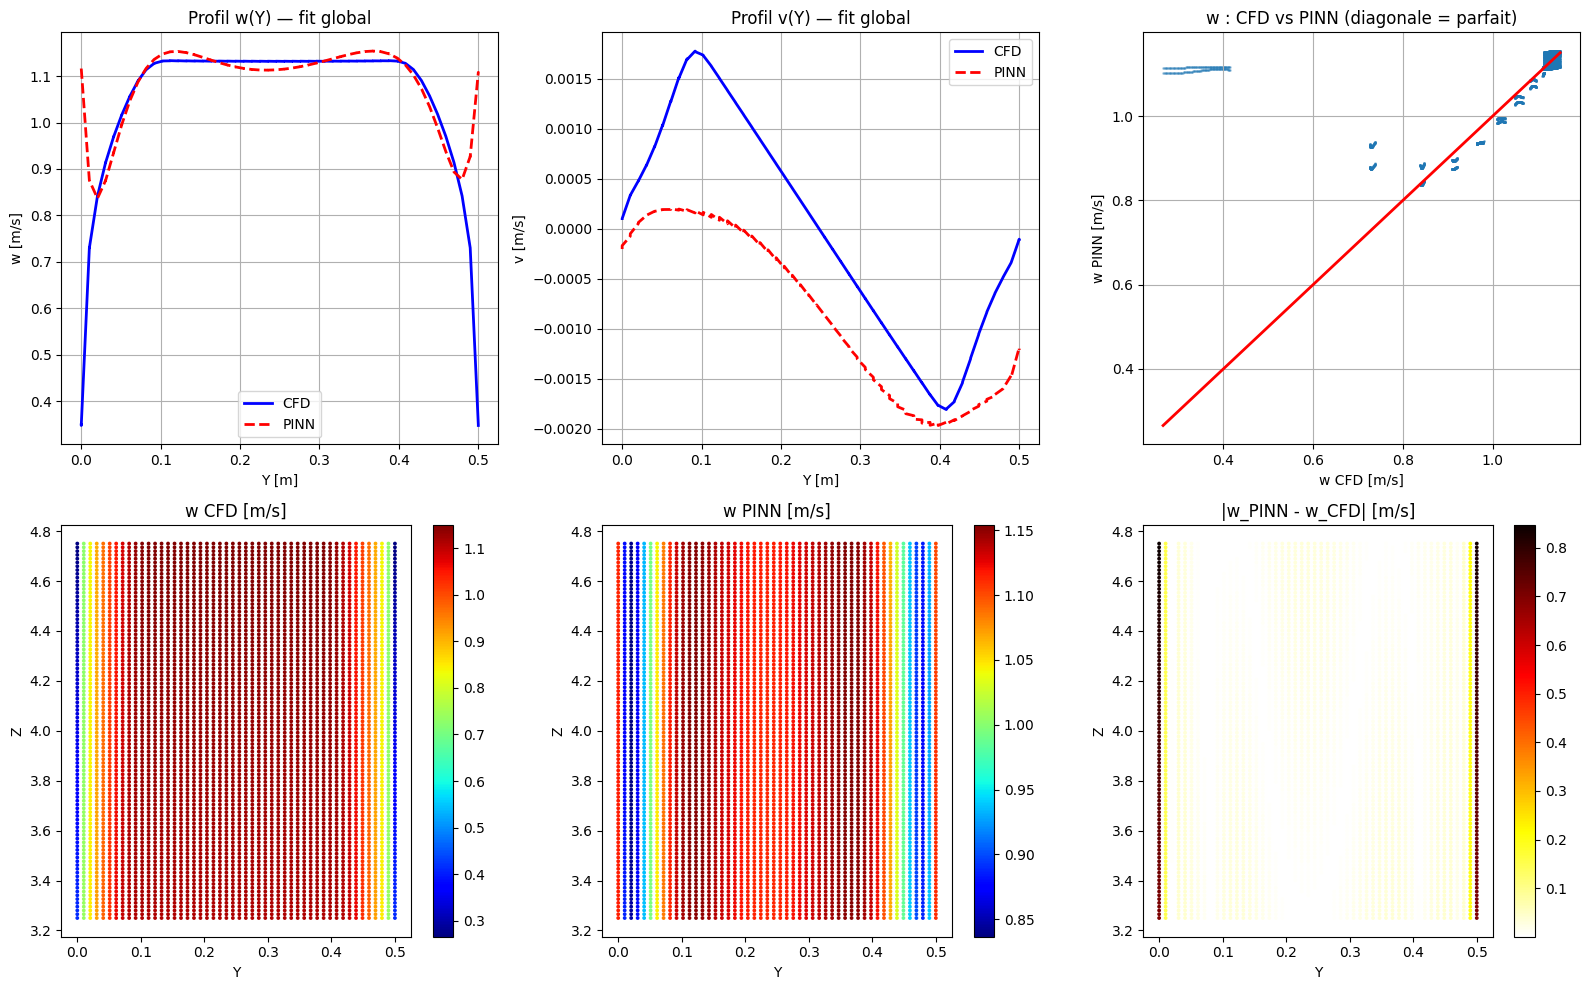

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# ── Évaluation du fit sur les données ────────────────────────────
model.eval()
with torch.no_grad():
    Y_ev = Y_t.clone().detach().requires_grad_(True)
    Z_ev = Z_t.clone().detach().requires_grad_(True)

with torch.enable_grad():
    v_pred, w_pred = model.get_vw(
        Y_t.clone().detach().requires_grad_(True),
        Z_t.clone().detach().requires_grad_(True)
    )

v_pred_np = v_pred.detach().cpu().numpy().flatten() * U_ref
w_pred_np = w_pred.detach().cpu().numpy().flatten() * U_ref
v_cfd_np  = v_adim * U_ref
w_cfd_np  = w_adim * U_ref

print("=== Qualité du fit ===")
print(f"Erreur L2 sur v : {np.sqrt(np.mean((v_pred_np - v_cfd_np)**2)):.6f} m/s")
print(f"Erreur L2 sur w : {np.sqrt(np.mean((w_pred_np - w_cfd_np)**2)):.6f} m/s")
print(f"Erreur relative v : {np.sqrt(np.mean((v_pred_np-v_cfd_np)**2))/np.std(v_cfd_np)*100:.1f}%")
print(f"Erreur relative w : {np.sqrt(np.mean((w_pred_np-w_cfd_np)**2))/np.std(w_cfd_np)*100:.1f}%")

# ── Visualisation fit ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Profil w(Y) à Z milieu
Z_mid_n = 0.5
mask = np.abs(Z_n - Z_mid_n) < 0.01
idx_sort = np.argsort(Y_n[mask])
axes[0,0].plot(Y_raw[mask][idx_sort], w_cfd_np[mask][idx_sort],
               'b-', label='CFD', linewidth=2)
axes[0,0].plot(Y_raw[mask][idx_sort], w_pred_np[mask][idx_sort],
               'r--', label='PINN', linewidth=2)
axes[0,0].set_xlabel('Y [m]'); axes[0,0].set_ylabel('w [m/s]')
axes[0,0].set_title('Profil w(Y) — fit global')
axes[0,0].legend(); axes[0,0].grid(True)

# Profil v(Y) à Z milieu
axes[0,1].plot(Y_raw[mask][idx_sort], v_cfd_np[mask][idx_sort],
               'b-', label='CFD', linewidth=2)
axes[0,1].plot(Y_raw[mask][idx_sort], v_pred_np[mask][idx_sort],
               'r--', label='PINN', linewidth=2)
axes[0,1].set_xlabel('Y [m]'); axes[0,1].set_ylabel('v [m/s]')
axes[0,1].set_title('Profil v(Y) — fit global')
axes[0,1].legend(); axes[0,1].grid(True)

# Scatter w CFD vs PINN
axes[0,2].scatter(w_cfd_np, w_pred_np, s=1, alpha=0.3)
axes[0,2].plot([w_cfd_np.min(), w_cfd_np.max()],
               [w_cfd_np.min(), w_cfd_np.max()], 'r-', linewidth=2)
axes[0,2].set_xlabel('w CFD [m/s]'); axes[0,2].set_ylabel('w PINN [m/s]')
axes[0,2].set_title('w : CFD vs PINN (diagonale = parfait)')
axes[0,2].grid(True)

# Champ w CFD
sc1 = axes[1,0].scatter(Y_raw, Z_raw, c=w_cfd_np, cmap='jet', s=3)
axes[1,0].set_title('w CFD [m/s]')
axes[1,0].set_xlabel('Y'); axes[1,0].set_ylabel('Z')
plt.colorbar(sc1, ax=axes[1,0])

# Champ w PINN
sc2 = axes[1,1].scatter(Y_raw, Z_raw, c=w_pred_np, cmap='jet', s=3)
axes[1,1].set_title('w PINN [m/s]')
axes[1,1].set_xlabel('Y'); axes[1,1].set_ylabel('Z')
plt.colorbar(sc2, ax=axes[1,1])

# Erreur pointwise
erreur = np.abs(w_pred_np - w_cfd_np)
sc3 = axes[1,2].scatter(Y_raw, Z_raw, c=erreur, cmap='hot_r', s=3)
axes[1,2].set_title('|w_PINN - w_CFD| [m/s]')
axes[1,2].set_xlabel('Y'); axes[1,2].set_ylabel('Z')
plt.colorbar(sc3, ax=axes[1,2])

plt.tight_layout()
plt.savefig('diagnostic_fit.png', dpi=150)
plt.show()

In [56]:
# ── Diagnostic des résidus NS avec λ₂ forcé à la valeur cible ────
print("\n=== Résidus NS avec λ₂ = 1/Re (valeur théorique) ===")

# On force temporairement λ₂ à sa valeur correcte
with torch.no_grad():
    model.log_lam2.fill_(-np.log(Re))

print(f"λ₂ forcé = {model.lambda2.item():.4e}")

ns_v_test, ns_w_test, cont_test = ns_residual_fixed(
    model,
    Y_t[:500].clone(),
    Z_t[:500].clone()
)

print(f"Résidu continuité  : {cont_test.abs().mean().item():.4e}")
print(f"Résidu NS_v        : {ns_v_test.abs().mean().item():.4e}")
print(f"Résidu NS_w        : {ns_w_test.abs().mean().item():.4e}")
print()
print("Si les résidus NS_v et NS_w sont >> continuité,")
print("le champ de vitesse prédit ne satisfait pas NS → problème de fit")
print()
print("Si les résidus sont tous petits → NS est satisfait,")
print("λ₂ est bien identifiable depuis ce champ")


=== Résidus NS avec λ₂ = 1/Re (valeur théorique) ===
λ₂ forcé = 2.5550e-05
Résidu continuité  : 5.2186e-03
Résidu NS_v        : 1.1866e-03
Résidu NS_w        : 7.1115e-03

Si les résidus NS_v et NS_w sont >> continuité,
le champ de vitesse prédit ne satisfait pas NS → problème de fit

Si les résidus sont tous petits → NS est satisfait,
λ₂ est bien identifiable depuis ce champ


# Nouvel essai

In [23]:
!pip install py7zr -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

Device : cuda


In [24]:
# Extraction du .7z
import py7zr
from google.colab import files

uploaded = files.upload()
archive_name = list(uploaded.keys())[0]
extract_dir = "/content/data/"

with py7zr.SevenZipFile(archive_name, mode='r') as z:
    z.extractall(path=extract_dir)

fichiers = sorted(os.listdir(extract_dir))
print(f"Nombre de fichiers : {len(fichiers)}")

def lire_fichier(path):
    df = pd.read_csv(path, skiprows=5)
    df.columns = ['X', 'Y', 'Z', 'u', 'v', 'w']
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)
    return df

# Moyenne sur tous les fichiers (quasi-stationnarité)
print("Chargement de tous les fichiers...")
dfs = [lire_fichier(os.path.join(extract_dir, f)) for f in fichiers]
df_mean = pd.concat(dfs).groupby(['Y', 'Z'], as_index=False).mean()
print(f"Points après moyennage : {len(df_mean)}")

Y_raw = df_mean['Y'].values.astype(np.float32)
Z_raw = df_mean['Z'].values.astype(np.float32)
v_raw = df_mean['v'].values.astype(np.float32)
w_raw = df_mean['w'].values.astype(np.float32)

print(f"Y : {Y_raw.min():.4f} → {Y_raw.max():.4f} m")
print(f"Z : {Z_raw.min():.4f} → {Z_raw.max():.4f} m")
print(f"v : {v_raw.min():.4f} → {v_raw.max():.4f} m/s")
print(f"w : {w_raw.min():.4f} → {w_raw.max():.4f} m/s")

Saving ProjetIA.7z to ProjetIA (1).7z
Nombre de fichiers : 200
Chargement de tous les fichiers...
Points après moyennage : 5000
Y : 0.0000 → 0.5000 m
Z : 3.2500 → 4.7500 m
v : -0.0020 → 0.0020 m/s
w : 0.2657 → 1.1502 m/s


In [25]:
# Grandeurs physiques de référence
rho   = 1.225       # kg/m³  densité air
mu    = 1.8e-5      # Pa·s   viscosité dynamique air
U_ref = float(w_raw.max())           # vitesse de référence
L_ref = float(Y_raw.max() - Y_raw.min())  # longueur de référence
Lz    = float(Z_raw.max() - Z_raw.min())
Re    = rho * U_ref * L_ref / mu

print(f"U_ref = {U_ref:.4f} m/s")
print(f"L_ref = {L_ref:.4f} m")
print(f"Re    = {Re:.0f}")
print(f"Cible λ₂ = 1/Re = {1/Re:.4e}")

# Normalisation des coordonnées → [0, 1]
Y_min, Y_max = Y_raw.min(), Y_raw.max()
Z_min, Z_max = Z_raw.min(), Z_raw.max()

Y_n = ((Y_raw - Y_min) / (Y_max - Y_min)).astype(np.float32)
Z_n = ((Z_raw - Z_min) / (Z_max - Z_min)).astype(np.float32)

# Adimensionnement des vitesses par U_ref
v_ad = (v_raw / U_ref).astype(np.float32)
w_ad = (w_raw / U_ref).astype(np.float32)

# Aspect ratio géométrique (pour les dérivées)
aspect = Lz / L_ref
print(f"Aspect ratio Lz/Ly = {aspect:.4f}")

# Tenseurs PyTorch
Y_t  = torch.tensor(Y_n,  dtype=torch.float32, device=device).unsqueeze(1)
Z_t  = torch.tensor(Z_n,  dtype=torch.float32, device=device).unsqueeze(1)
v_t  = torch.tensor(v_ad, dtype=torch.float32, device=device).unsqueeze(1)
w_t  = torch.tensor(w_ad, dtype=torch.float32, device=device).unsqueeze(1)

print("Tenseurs créés ")

U_ref = 1.1502 m/s
L_ref = 0.5000 m
Re    = 39139
Cible λ₂ = 1/Re = 2.5550e-05
Aspect ratio Lz/Ly = 3.0000
Tenseurs créés 


In [26]:
# On utilise les points CFD aux bords Y=0 et Y=0.5
# comme conditions aux limites imposées
idx_Y0   = np.where(Y_raw == Y_min)[0]
idx_Ymax = np.where(Y_raw == Y_max)[0]
idx_bc   = np.concatenate([idx_Y0, idx_Ymax])

Y_bc = torch.tensor(Y_n[idx_bc],  dtype=torch.float32, device=device).unsqueeze(1)
Z_bc = torch.tensor(Z_n[idx_bc],  dtype=torch.float32, device=device).unsqueeze(1)
v_bc = torch.tensor(v_ad[idx_bc], dtype=torch.float32, device=device).unsqueeze(1)
w_bc = torch.tensor(w_ad[idx_bc], dtype=torch.float32, device=device).unsqueeze(1)

print(f"Points de bord Y=0   : {len(idx_Y0)}")
print(f"Points de bord Y=0.5 : {len(idx_Ymax)}")
print(f"Total BC             : {len(idx_bc)}")

Points de bord Y=0   : 100
Points de bord Y=0.5 : 100
Total BC             : 200


In [27]:
class PINN(nn.Module):
    """
    Entrées  : (Y_n, Z_n) ∈ [0,1]²
    Sorties  : (v_ad, w_ad, p_ad) — vitesses et pression adimensionnées
    Paramètre appris : λ₂ = 1/Re (viscosité adimensionnée)
    λ₁ = 1 fixé (densité adimensionnée = 1 par définition)
    """
    def __init__(self, hidden_layers=8, neurons=128):
        super().__init__()

        layers = [nn.Linear(2, neurons), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(neurons, neurons), nn.Tanh()]
        layers += [nn.Linear(neurons, 3)]  # sorties : v, w, p
        self.net = nn.Sequential(*layers)

        # Initialisation Xavier pour Tanh
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

        # On apprend log(λ₂) pour forcer λ₂ > 0
        # Initialisé à log(1/Re) = valeur physique exacte
        self.log_lam2 = nn.Parameter(
            torch.tensor([-np.log(Re)], dtype=torch.float32, device=device)
        )

    @property
    def lambda2(self):
        return torch.exp(self.log_lam2)

    def forward(self, Y, Z):
        inp = torch.cat([Y, Z], dim=1)
        out = self.net(inp)
        return out[:, 0:1], out[:, 1:2], out[:, 2:3]  # v, w, p

model = PINN(hidden_layers=8, neurons=128).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres totaux : {n_params:,}")
print(f"λ₂ initial = {model.lambda2.item():.4e}  (cible : {1/Re:.4e})")

Paramètres totaux : 116,356
λ₂ initial = 2.5550e-05  (cible : 2.5550e-05)


In [28]:
def ns_residual(model, Y, Z):
    """
    Calcule les résidus NS adimensionnés.
    Toutes les grandeurs sont adimensionnées par U_ref et L_ref.
    λ₁ = 1 fixé, λ₂ appris.
    """
    Y = Y.clone().detach().requires_grad_(True)
    Z = Z.clone().detach().requires_grad_(True)

    def g(f, x):
        return torch.autograd.grad(
            f, x,
            grad_outputs=torch.ones_like(f),
            create_graph=True
        )[0]

    v, w, p = model(Y, Z)

    # Dérivées premières
    # Note : ∂/∂Z_physique = (1/aspect) * ∂/∂Z_normalisé
    v_Y = g(v, Y);            v_Z = g(v, Z) / aspect
    w_Y = g(w, Y);            w_Z = g(w, Z) / aspect
    p_Y = g(p, Y);            p_Z = g(p, Z) / aspect

    # Dérivées secondes
    v_YY = g(g(v, Y), Y)
    v_ZZ = g(g(v, Z), Z) / aspect**2
    w_YY = g(g(w, Y), Y)
    w_ZZ = g(g(w, Z), Z) / aspect**2

    lam2 = model.lambda2

    # Continuité : ∂v/∂Y + ∂w/∂Z = 0
    cont = v_Y + w_Z

    # NS momentum v : v∂v/∂Y + w∂v/∂Z + ∂p/∂Y - λ₂∇²v = 0
    ns_v = v*v_Y + w*v_Z + p_Y - lam2*(v_YY + v_ZZ)

    # NS momentum w : v∂w/∂Y + w∂w/∂Z + ∂p/∂Z - λ₂∇²w = 0
    ns_w = v*w_Y + w*w_Z + p_Z - lam2*(w_YY + w_ZZ)

    return cont, ns_v, ns_w

In [29]:
def compute_loss(w_phys_cur, n_col=1000, log=False):
    """
    Loss totale = loss_data + w_phys * loss_physique + loss_BC + loss_reg
    """
    # ── 1. Loss données ───────────────────────────────────────────
    v_p, w_p, _ = model(Y_t, Z_t)
    loss_data = (torch.mean((v_p - v_t)**2) +
                 torch.mean((w_p - w_t)**2))

    # ── 2. Loss physique (NS + continuité) ────────────────────────
    idx  = torch.randperm(len(Y_t), device=device)[:n_col]
    cont, ns_v, ns_w = ns_residual(model, Y_t[idx], Z_t[idx])
    loss_phys = (torch.mean(cont**2) +
                 torch.mean(ns_v**2) +
                 torch.mean(ns_w**2))

    # ── 3. Loss conditions aux limites ────────────────────────────
    v_bp, w_bp, _ = model(Y_bc, Z_bc)
    loss_bc = (torch.mean((v_bp - v_bc)**2) +
               torch.mean((w_bp - w_bc)**2))

    # ── 4. Régularisation faible sur λ₂ ──────────────────────────
    # Pénalise si λ₂ s'éloigne trop de 1/Re en échelle log
    # Poids faible (0.01) : guide sans forcer
    lam2_target = torch.tensor(1.0/Re, device=device)
    loss_reg = (model.log_lam2 - torch.log(lam2_target))**2

    # ── Loss totale ───────────────────────────────────────────────
    loss = (1.0  * loss_data  +
            w_phys_cur * loss_phys +
            1.0  * loss_bc    +
            0.01 * loss_reg)

    if log:
        loss_history['total'].append(loss.item())
        loss_history['data'].append(loss_data.item())
        loss_history['phys'].append(loss_phys.item())
        loss_history['bc'].append(loss_bc.item())
        loss_history['lambda2'].append(model.lambda2.item())

    return loss, loss_data, loss_phys, loss_bc

In [31]:
loss_history = {k: [] for k in ['total', 'data', 'phys', 'bc', 'lambda2']}

# ─────────────────────────────────────────────────────────────────
# Pré-entraînement : données seules, pour bien fitter avant physique
# ─────────────────────────────────────────────────────────────────
print("=== Pré-entraînement (data only) ===")
optimizer_pre = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3000):
    optimizer_pre.zero_grad()
    v_p, w_p, _ = model(Y_t, Z_t)
    loss_pre = (torch.mean((v_p - v_t)**2) +
                torch.mean((w_p - w_t)**2))
    loss_pre.backward()
    optimizer_pre.step()
    if epoch % 500 == 0:
        print(f"  Epoch {epoch:4d} | Loss data : {loss_pre.item():.4e}")

with torch.no_grad():
    v_c, w_c, _ = model(Y_t, Z_t)
    err_v = torch.sqrt(torch.mean((v_c - v_t)**2)).item() * U_ref
    err_w = torch.sqrt(torch.mean((w_c - w_t)**2)).item() * U_ref
print(f"\nErreur L2 après pré-entraînement :")
print(f"  v : {err_v:.5f} m/s")
print(f"  w : {err_w:.5f} m/s")

# ─────────────────────────────────────────────────────────────────
# Phase 1 : Adam + physique avec curriculum
# ─────────────────────────────────────────────────────────────────
print("\n=== Phase 1 : Adam + physique ===")
optimizer_adam = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = ReduceLROnPlateau(optimizer_adam, patience=1000,
                               factor=0.5, min_lr=1e-6)
N_adam = 10000

for epoch in range(N_adam):
    # Curriculum exponentiel : 0.001 → 0.1
    w_phys_cur = 0.001 * (100 ** (epoch / N_adam))

    optimizer_adam.zero_grad()
    loss, ld, lp, lbc = compute_loss(w_phys_cur, log=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer_adam.step()
    scheduler.step(loss)

    if epoch % 1000 == 0:
        with torch.no_grad():
            v_c, w_c, _ = model(Y_t, Z_t)
            err_w = torch.sqrt(torch.mean((w_c - w_t)**2)).item() * U_ref
        lr_cur = optimizer_adam.param_groups[0]['lr']
        print(f"[Adam] {epoch:5d} | "
              f"Loss:{loss.item():.3e} | "
              f"Data:{ld.item():.3e} | "
              f"Phys:{lp.item():.3e} | "
              f"ErrW:{err_w:.4f}m/s | "
              f"λ₂:{model.lambda2.item():.4e} | "
              f"cible:{1/Re:.4e} | "
              f"lr:{lr_cur:.1e}")

print(f"\nFin Adam → λ₂ = {model.lambda2.item():.4e}  (cible : {1/Re:.4e})")

# ─────────────────────────────────────────────────────────────────
# Phase 2 : L-BFGS pour affiner
# ─────────────────────────────────────────────────────────────────
print("\n=== Phase 2 : L-BFGS ===")
w_phys_cur = 0.1

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=0.1,
    max_iter=50000,
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
    history_size=50,
    line_search_fn='strong_wolfe'
)

it = [0]
def closure():
    optimizer_lbfgs.zero_grad()
    loss, ld, lp, lbc = compute_loss(w_phys_cur, log=True)
    loss.backward()
    it[0] += 1
    if it[0] % 500 == 0:
        print(f"[L-BFGS] {it[0]:5d} | "
              f"Loss:{loss.item():.3e} | "
              f"λ₂:{model.lambda2.item():.4e} | "
              f"cible:{1/Re:.4e}")
    return loss

optimizer_lbfgs.step(closure)

=== Pré-entraînement (data only) ===
  Epoch    0 | Loss data : 1.6231e-03
  Epoch  500 | Loss data : 2.7946e-03
  Epoch 1000 | Loss data : 5.9594e-04
  Epoch 1500 | Loss data : 5.4024e-04
  Epoch 2000 | Loss data : 7.1056e-04
  Epoch 2500 | Loss data : 5.3621e-04

Erreur L2 après pré-entraînement :
  v : 0.00227 m/s
  w : 0.03636 m/s

=== Phase 1 : Adam + physique ===


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


[Adam]     0 | Loss:6.031e-03 | Data:1.003e-03 | Phys:1.232e-01 | ErrW:0.5221m/s | λ₂:2.5559e-05 | cible:2.5550e-05 | lr:5.0e-04
[Adam]  1000 | Loss:1.136e-03 | Data:6.956e-04 | Phys:3.026e-03 | ErrW:0.0366m/s | λ₂:2.5549e-05 | cible:2.5550e-05 | lr:5.0e-04
[Adam]  2000 | Loss:1.315e-04 | Data:1.250e-04 | Phys:7.880e-04 | ErrW:0.0126m/s | λ₂:2.5550e-05 | cible:2.5550e-05 | lr:5.0e-04
[Adam]  3000 | Loss:2.243e-04 | Data:1.860e-04 | Phys:1.828e-03 | ErrW:0.0353m/s | λ₂:2.5546e-05 | cible:2.5550e-05 | lr:5.0e-04
[Adam]  4000 | Loss:3.729e-05 | Data:3.282e-05 | Phys:3.974e-04 | ErrW:0.0066m/s | λ₂:2.5548e-05 | cible:2.5550e-05 | lr:2.5e-04
[Adam]  5000 | Loss:1.922e-04 | Data:3.645e-05 | Phys:3.130e-04 | ErrW:0.0088m/s | λ₂:2.5547e-05 | cible:2.5550e-05 | lr:2.5e-04
[Adam]  6000 | Loss:1.526e-05 | Data:1.034e-05 | Phys:2.591e-04 | ErrW:0.0037m/s | λ₂:2.5546e-05 | cible:2.5550e-05 | lr:2.5e-04
[Adam]  7000 | Loss:1.509e-02 | Data:1.049e-02 | Phys:7.090e-02 | ErrW:0.0916m/s | λ₂:2.5558e-05 

tensor([2.1953e-05], device='cuda:0', grad_fn=<AddBackward0>)

=== Résultats finaux ===
λ₂ identifié = 2.552955e-05
Cible 1/Re   = 2.554970e-05
Erreur       = 0.08%
Re identifié = 39170  (Re réel = 39139)

Viscosité effective  μ_eff = 1.7986e-05 Pa·s
Viscosité laminaire  μ_lam = 1.8000e-05 Pa·s
Ratio μ_eff/μ_lam = 1.0x


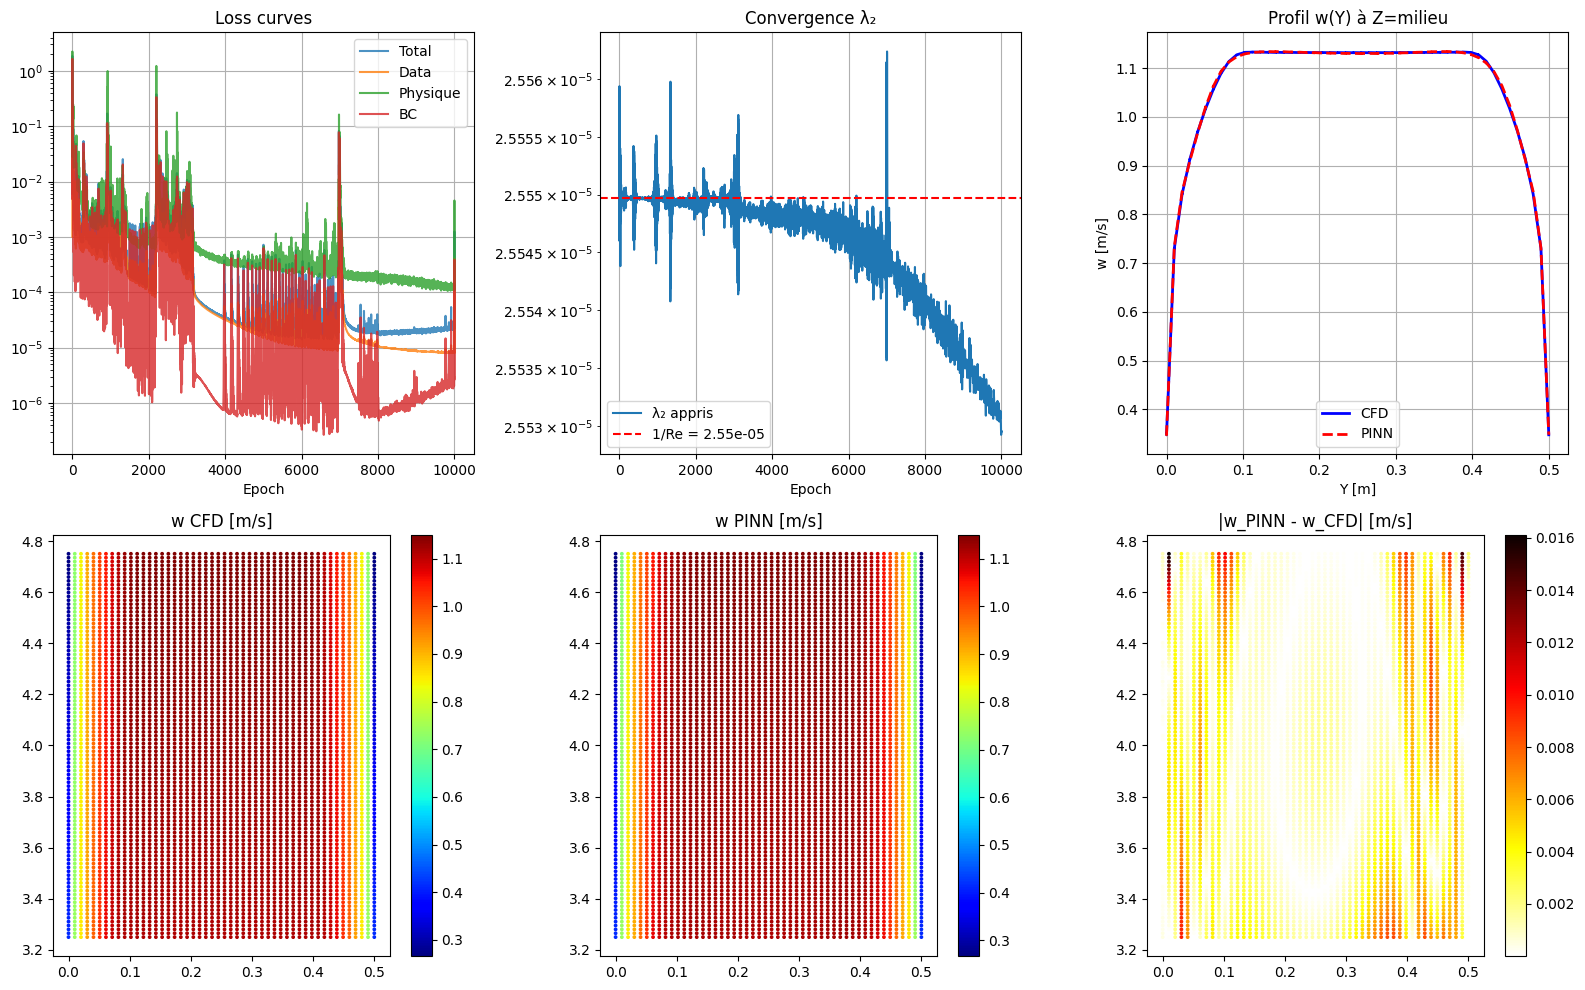

In [32]:
# ── Résultats numériques ──────────────────────────────────────────
lam2_final = model.lambda2.item()
mu_eff     = lam2_final * rho * U_ref * L_ref

print("=== Résultats finaux ===")
print(f"λ₂ identifié = {lam2_final:.6e}")
print(f"Cible 1/Re   = {1/Re:.6e}")
print(f"Erreur       = {abs(lam2_final - 1/Re)/(1/Re)*100:.2f}%")
print(f"Re identifié = {1/lam2_final:.0f}  (Re réel = {Re:.0f})")
print(f"\nViscosité effective  μ_eff = {mu_eff:.4e} Pa·s")
print(f"Viscosité laminaire  μ_lam = {mu:.4e} Pa·s")
print(f"Ratio μ_eff/μ_lam = {mu_eff/mu:.1f}x")

# ── Visualisation ─────────────────────────────────────────────────
with torch.no_grad():
    v_pred, w_pred, _ = model(Y_t, Z_t)
    v_pred_np = v_pred.cpu().numpy().flatten() * U_ref
    w_pred_np = w_pred.cpu().numpy().flatten() * U_ref

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Loss curves
axes[0,0].semilogy(loss_history['total'], label='Total',    alpha=0.8)
axes[0,0].semilogy(loss_history['data'],  label='Data',     alpha=0.8)
axes[0,0].semilogy(loss_history['phys'],  label='Physique', alpha=0.8)
axes[0,0].semilogy(loss_history['bc'],    label='BC',       alpha=0.8)
axes[0,0].set_title('Loss curves'); axes[0,0].legend()
axes[0,0].set_xlabel('Epoch'); axes[0,0].grid(True)

# 2. Convergence λ₂
axes[0,1].semilogy(loss_history['lambda2'], label='λ₂ appris')
axes[0,1].axhline(1/Re, color='r', linestyle='--', label=f'1/Re = {1/Re:.2e}')
axes[0,1].set_title('Convergence λ₂'); axes[0,1].legend()
axes[0,1].set_xlabel('Epoch'); axes[0,1].grid(True)

# 3. Profil w(Y)
Z_mid = 0.5
mask = np.abs(Z_n - Z_mid) < 0.01
idx_s = np.argsort(Y_n[mask])
axes[0,2].plot(Y_raw[mask][idx_s], w_raw[mask][idx_s],
               'b-', linewidth=2, label='CFD')
axes[0,2].plot(Y_raw[mask][idx_s], w_pred_np[mask][idx_s],
               'r--', linewidth=2, label='PINN')
axes[0,2].set_xlabel('Y [m]'); axes[0,2].set_ylabel('w [m/s]')
axes[0,2].set_title('Profil w(Y) à Z=milieu')
axes[0,2].legend(); axes[0,2].grid(True)

# 4. Champ w CFD
sc1 = axes[1,0].scatter(Y_raw, Z_raw, c=w_raw,     cmap='jet', s=3)
axes[1,0].set_title('w CFD [m/s]')
plt.colorbar(sc1, ax=axes[1,0])

# 5. Champ w PINN
sc2 = axes[1,1].scatter(Y_raw, Z_raw, c=w_pred_np, cmap='jet', s=3)
axes[1,1].set_title('w PINN [m/s]')
plt.colorbar(sc2, ax=axes[1,1])

# 6. Erreur pointwise
sc3 = axes[1,2].scatter(Y_raw, Z_raw,
                         c=np.abs(w_pred_np - w_raw), cmap='hot_r', s=3)
axes[1,2].set_title('|w_PINN - w_CFD| [m/s]')
plt.colorbar(sc3, ax=axes[1,2])

plt.tight_layout()
plt.savefig('resultats_finaux.png', dpi=150)
plt.show()

In [34]:
class PINN_v2(nn.Module):
    def __init__(self, hidden_layers=8, neurons=128,
                 log_lam2_init=None):
        super().__init__()

        layers = [nn.Linear(2, neurons), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(neurons, neurons), nn.Tanh()]
        layers += [nn.Linear(neurons, 3)]
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

        # Initialisation loin de la cible pour tester la convergence
        if log_lam2_init is None:
            log_lam2_init = 0.0  # λ₂ = exp(0) = 1.0, soit 40000x trop grand
        self.log_lam2 = nn.Parameter(
            torch.tensor([log_lam2_init], dtype=torch.float32, device=device)
        )

    @property
    def lambda2(self):
        return torch.exp(self.log_lam2)

    def forward(self, Y, Z):
        inp = torch.cat([Y, Z], dim=1)
        out = self.net(inp)
        return out[:,0:1], out[:,1:2], out[:,2:3]


# Test avec 3 initialisations différentes, sans régularisation
initialisations = {
    'λ₂=1.0    (x40000 trop grand)' : 0.0,
    'λ₂=1e-3   (x40 trop grand)'   : np.log(1e-3),
    'λ₂=1e-7   (x250 trop petit)'  : np.log(1e-7),
}

print(f"Cible : λ₂ = {1/Re:.4e}\n")

for nom, init_val in initialisations.items():
    torch.manual_seed(42)
    model_test = PINN_v2(log_lam2_init=init_val).to(device)
    print(f"=== Init {nom} ===")
    print(f"  λ₂ départ = {model_test.lambda2.item():.4e}")

    # Pré-entraînement data only
    opt = torch.optim.Adam(model_test.parameters(), lr=1e-3)
    for ep in range(3000):
        opt.zero_grad()
        v_p, w_p, _ = model_test(Y_t, Z_t)
        l = torch.mean((v_p-v_t)**2) + torch.mean((w_p-w_t)**2)
        l.backward()
        opt.step()

    # Phase physique SANS régularisation sur λ₂
    opt2 = torch.optim.Adam(model_test.parameters(), lr=5e-4)
    for ep in range(10000):
        w_phys_cur = 0.001 * (100 ** (ep / 10000))
        opt2.zero_grad()

        v_p, w_p, _ = model_test(Y_t, Z_t)
        loss_data = torch.mean((v_p-v_t)**2) + torch.mean((w_p-w_t)**2)

        idx = torch.randperm(len(Y_t), device=device)[:1000]
        cont, ns_v, ns_w = ns_residual(model_test, Y_t[idx], Z_t[idx])
        loss_phys = (torch.mean(cont**2) +
                     torch.mean(ns_v**2) +
                     torch.mean(ns_w**2))

        v_bp, w_bp, _ = model_test(Y_bc, Z_bc)
        loss_bc = (torch.mean((v_bp-v_bc)**2) +
                   torch.mean((w_bp-w_bc)**2))

        # PAS de loss_reg ici !
        loss = loss_data + w_phys_cur*loss_phys + loss_bc
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_test.parameters(), max_norm=1.0)
        opt2.step()

    lam2_final = model_test.lambda2.item()
    erreur = abs(lam2_final - 1/Re) / (1/Re) * 100
    print(f"  λ₂ final  = {lam2_final:.4e}")
    print(f"  Erreur    = {erreur:.2f}%\n")

Cible : λ₂ = 2.5550e-05

=== Init λ₂=1.0    (x40000 trop grand) ===
  λ₂ départ = 1.0000e+00
  λ₂ final  = 1.4356e-02
  Erreur    = 56087.71%

=== Init λ₂=1e-3   (x40 trop grand) ===
  λ₂ départ = 1.0000e-03
  λ₂ final  = 9.6553e-06
  Erreur    = 62.21%

=== Init λ₂=1e-7   (x250 trop petit) ===
  λ₂ départ = 1.0000e-07
  λ₂ final  = 5.1744e-08
  Erreur    = 99.80%



In [37]:
# ── Option A : Identification de Re ──────────────────────────────

def train_pinn_Re(Re_init, seed=42, n_pretrain=3000, n_adam=10000):
    """
    Entraîne un PINN avec Re_init comme valeur de départ.
    Retourne Re_final et l'historique de convergence.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ── Modèle ───────────────────────────────────────────────────
    model_A = PINN(hidden_layers=8, neurons=128).to(device)

    # On initialise log_lam2 = -log(Re_init)
    with torch.no_grad():
        model_A.log_lam2.fill_(-np.log(Re_init))

    print(f"  Re départ  = {Re_init:.0f}  "
          f"→ λ₂ = {model_A.lambda2.item():.4e}")

    # ── Pré-entraînement data only ────────────────────────────────
    opt_pre = torch.optim.Adam(model_A.parameters(), lr=1e-3)
    for ep in range(n_pretrain):
        opt_pre.zero_grad()
        v_p, w_p, _ = model_A(Y_t, Z_t)
        loss = torch.mean((v_p - v_t)**2) + torch.mean((w_p - w_t)**2)
        loss.backward()
        opt_pre.step()

    # ── Phase Adam + physique, SANS régularisation ────────────────
    opt_adam = torch.optim.Adam(model_A.parameters(), lr=5e-4)
    scheduler = ReduceLROnPlateau(opt_adam, patience=1000,
                                   factor=0.5, min_lr=1e-6)
    Re_history = []

    for ep in range(n_adam):
        w_phys_cur = 0.001 * (100 ** (ep / n_adam))

        opt_adam.zero_grad()

        # Loss données
        v_p, w_p, _ = model_A(Y_t, Z_t)
        loss_data = (torch.mean((v_p - v_t)**2) +
                     torch.mean((w_p - w_t)**2))

        # Loss physique
        idx = torch.randperm(len(Y_t), device=device)[:1000]
        cont, ns_v, ns_w = ns_residual(model_A, Y_t[idx], Z_t[idx])
        loss_phys = (torch.mean(cont**2) +
                     torch.mean(ns_v**2) +
                     torch.mean(ns_w**2))

        # Loss BC
        v_bp, w_bp, _ = model_A(Y_bc, Z_bc)
        loss_bc = (torch.mean((v_bp - v_bc)**2) +
                   torch.mean((w_bp - w_bc)**2))

        loss = loss_data + w_phys_cur * loss_phys + loss_bc
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_A.parameters(), max_norm=1.0)
        opt_adam.step()
        scheduler.step(loss.detach())

        # On suit Re = 1/λ₂
        Re_cur = (1.0 / model_A.lambda2.item())
        Re_history.append(Re_cur)

    # ── L-BFGS ───────────────────────────────────────────────────
    w_phys_cur = 0.1
    opt_lbfgs = torch.optim.LBFGS(
        model_A.parameters(), lr=0.1, max_iter=10000,
        tolerance_grad=1e-9, tolerance_change=1e-11,
        history_size=50, line_search_fn='strong_wolfe')

    def closure():
        opt_lbfgs.zero_grad()
        v_p, w_p, _ = model_A(Y_t, Z_t)
        ld = torch.mean((v_p-v_t)**2) + torch.mean((w_p-w_t)**2)
        idx = torch.randperm(len(Y_t), device=device)[:1000]
        c, nv, nw = ns_residual(model_A, Y_t[idx], Z_t[idx])
        lp = torch.mean(c**2) + torch.mean(nv**2) + torch.mean(nw**2)
        v_bp, w_bp, _ = model_A(Y_bc, Z_bc)
        lbc = torch.mean((v_bp-v_bc)**2) + torch.mean((w_bp-w_bc)**2)
        loss = ld + w_phys_cur*lp + lbc
        loss.backward()
        Re_history.append(1.0 / model_A.lambda2.item())
        return loss

    opt_lbfgs.step(closure)

    Re_final = 1.0 / model_A.lambda2.item()
    return Re_final, Re_history

In [38]:
# ── Test sur 5 initialisations très différentes ───────────────────

Re_reel = Re  # 39 139

initialisations = {
    'Re=100     (laminaire)' : 100,
    'Re=1 000'               : 1_000,
    'Re=10 000'              : 10_000,
    'Re=39 139  (cible)'     : 39_139,
    'Re=500 000'             : 500_000,
}

resultats = {}
histories = {}

print(f"Re réel = {Re_reel:.0f}\n")
print("="*60)

for nom, Re_init in initialisations.items():
    print(f"\n>>> {nom}")
    Re_final, history = train_pinn_Re(Re_init)
    erreur = abs(Re_final - Re_reel) / Re_reel * 100
    resultats[nom] = Re_final
    histories[nom] = history
    print(f"  Re final   = {Re_final:.0f}")
    print(f"  Erreur     = {erreur:.1f}%")
    print("-"*40)

# ── Résumé ────────────────────────────────────────────────────────
print("\n=== RÉSUMÉ ===")
print(f"{'Initialisation':<25} {'Re_init':>10} {'Re_final':>10} {'Erreur':>8}")
print("-"*55)
for nom, Re_init in initialisations.items():
    Re_f = resultats[nom]
    err  = abs(Re_f - Re_reel) / Re_reel * 100
    print(f"{nom:<25} {Re_init:>10.0f} {Re_f:>10.0f} {err:>7.1f}%")

Re réel = 39139


>>> Re=100     (laminaire)
  Re départ  = 100  → λ₂ = 1.0000e-02
  Re final   = 10878
  Erreur     = 72.2%
----------------------------------------

>>> Re=1 000
  Re départ  = 1000  → λ₂ = 1.0000e-03
  Re final   = 59970
  Erreur     = 53.2%
----------------------------------------

>>> Re=10 000
  Re départ  = 10000  → λ₂ = 1.0000e-04
  Re final   = 224618
  Erreur     = 473.9%
----------------------------------------

>>> Re=39 139  (cible)
  Re départ  = 39139  → λ₂ = 2.5550e-05
  Re final   = 547054
  Erreur     = 1297.7%
----------------------------------------

>>> Re=500 000
  Re départ  = 500000  → λ₂ = 2.0000e-06
  Re final   = 1770319
  Erreur     = 4423.1%
----------------------------------------

=== RÉSUMÉ ===
Initialisation               Re_init   Re_final   Erreur
-------------------------------------------------------
Re=100     (laminaire)           100      10878    72.2%
Re=1 000                        1000      59970    53.2%
Re=10 000            